# RPA Model Class

A generic `RPAModel` class for the six SN5.2 networks from Araujo & Liotta (2018).

Each model is defined once — ODE equations written in **SymPy**, base parameter values, and the output variable name. Everything else is automatic:
- Steady-state O* is solved analytically.
- RPA parameters (∂O*/∂k = 0) are identified by symbolic differentiation.
- A `scipy`-compatible ODE is produced via `lambdify`.

The test suite validates the RPA parameter list numerically.

In [49]:
import numpy as np
from scipy.integrate import solve_ivp
from sympy import symbols, solve, simplify, diff, lambdify, Integer
import matplotlib.pyplot as plt
from rpa_control.paths import save_fig

In [2]:
class RPAModel:
    """
    RPA ODE model defined symbolically with SymPy.

    Parameters
    ----------
    name        : short label
    state_vars  : ordered list of state-variable name strings
    output_var  : name of the output variable (must appear in state_vars)
    params_base : dict of base values for every parameter, including 'Input'
    equations   : list of sympy expressions — the RHS of dxi/dt in the same
                  order as state_vars, written using symbols whose names match
                  state_vars and params_base keys (all declared positive=True)
    extra_vars  : optional list of extra variable name strings appended after
                  the homeostatic state vars (e.g. ['Cancer']).  Their SS is
                  set to 0.  They are excluded from the sympy solve.
    extra_f     : callable(t, y_full, O_star_num) -> list of derivatives for
                  the extra variables, evaluated at every ODE step.

    Attributes set automatically
    ----------------------------
    O_star_sym  : sympy expression for the analytic steady-state of output_var
    O_star_num  : float — numerical O* at baseline parameters
    rpa_params  : list of parameter names with ∂O*/∂k = 0, including 'Input'
                  when O* is independent of the input signal
    """

    def __init__(self, name, state_vars, output_var, params_base, equations,
                 extra_vars=None, extra_f=None):
        self.name        = name
        self.state_vars  = list(state_vars)
        self.output_var  = output_var
        self.output_idx  = self.state_vars.index(output_var)
        self.params_base = dict(params_base)
        self._equations  = list(equations)

        self._sym_state   = [symbols(v, positive=True) for v in state_vars]
        self._param_names = [k for k in params_base if k != 'Input']
        self._sym_params  = [symbols(k, positive=True) for k in self._param_names]
        self._sym_input   = symbols('Input', positive=True)

        # ── 1. analytic steady state ──────────────────────────────────────
        self._ss_dict   = self._solve_ss()
        O_sym           = self._sym_state[self.output_idx]
        self.O_star_sym = simplify(self._ss_dict[O_sym])

        # ── 2. RPA parameters: ∂O*/∂k = 0 ────────────────────────────────
        self.rpa_params = [
            name for name, sym in zip(self._param_names, self._sym_params)
            if diff(self.O_star_sym, sym) == 0
        ]
        # Input is also an RPA parameter when O* does not depend on it
        if diff(self.O_star_sym, self._sym_input) == 0:
            self.rpa_params.append('Input')

        # ── 3. lambdify ODE once ──────────────────────────────────────────
        _args       = self._sym_state + self._sym_params + [self._sym_input]
        self._f_lam = lambdify(_args, self._equations, modules='numpy')

        # ── 4. extra (non-homeostatic) variables ──────────────────────────
        self._extra_vars = list(extra_vars) if extra_vars else []
        self._extra_f    = extra_f

        # numerical O* at baseline (constant under RPA; used by extra_f)
        _base_subs = {sym: self.params_base[name]
                      for name, sym in zip(self._param_names, self._sym_params)}
        _base_subs[self._sym_input] = self.params_base['Input']
        self.O_star_num = float(self.O_star_sym.subs(_base_subs))

        if self._extra_vars:
            self.state_vars = self.state_vars + self._extra_vars
            for vname in self._extra_vars:
                vsym = symbols(vname, positive=True)
                self._sym_state.append(vsym)
                self._ss_dict[vsym] = Integer(0)

    # ── private ───────────────────────────────────────────────────────────────

    def _solve_ss(self):
        sols = solve(self._equations, self._sym_state, dict=True)
        if not sols:
            raise ValueError(f"[{self.name}] No analytic steady-state found.")
        return sols[0]

    # ── public API ────────────────────────────────────────────────────────────

    def get_f(self, rpa_overrides=None):
        """Return f(t, y) -> dydt for scipy.integrate.solve_ivp."""
        p     = dict(self.params_base)
        if rpa_overrides:
            p.update(rpa_overrides)
        pvals   = [p[k] for k in self._param_names] + [p['Input']]
        f_lam   = self._f_lam
        extra_f = self._extra_f
        O_star  = self.O_star_num
        n_base  = len(self.state_vars) - len(self._extra_vars)

        if extra_f is None:
            def f(t, y):
                return f_lam(*y, *pvals)
        else:
            def f(t, y):
                return list(f_lam(*y[:n_base], *pvals)) + list(extra_f(t, y, O_star))
        return f

    def _repr_latex_(self):
        from sympy import latex as sym_latex

        # ODE rows — aligned at '='
        ode_rows = r' \\'.join(
            r'\dot{' + sym_latex(sv) + r'} &= ' + sym_latex(eq)
            for sv, eq in zip(self._sym_state, self._equations)
        )

        # Steady-state row
        O_sym   = self._sym_state[self.output_idx]
        ss_row  = sym_latex(O_sym) + r'^{*} &= ' + sym_latex(self.O_star_sym)

        # RPA params row
        rpa_str = r',\;'.join(
            r'\text{Input}' if p == 'Input' else sym_latex(symbols(p, positive=True))
            for p in self.rpa_params
        )
        rpa_row = r'\text{RPA params} &:\; ' + rpa_str

        body = (
            r'& \textbf{Case\;' + self.name + r'} \\[4pt]'
            + ode_rows
            + r' \\[6pt]'
            + ss_row
            + r' \\[6pt]'
            + rpa_row
        )
        return r'$$\begin{aligned}' + body + r'\end{aligned}$$'

    def __repr__(self):
        return (f"RPAModel('{self.name}', output='{self.output_var}', "
                f"rpa_params={self.rpa_params})")


## Model definitions (cases a – f)

Each model is fully specified by its **SymPy equations** and **base parameter values**.  
`rpa_params` and `O_star_sym` are derived automatically — no hand-annotation required.

> **Symbol note:** the biochemical signal node named *I* is written as the Python variable `Iv`  
> (holding `Symbol('I', positive=True)`) to avoid shadowing SymPy's imaginary unit.

In [77]:
# ── shared symbols ────────────────────────────────────────────────────────────
# State-variable symbols.  Iv = Symbol('I', positive=True) — the signal node.
Iv, O, O1, O2, O3 = symbols('I  O  O1  O2  O3', positive=True)
B,  C,  X,  X1, X2 = symbols('B  C  X   X1  X2', positive=True)

Input_sym = symbols('Input', positive=True)

# All 18 kinetic-parameter symbols used across all cases
(k1, k2, k3, k4, k5, k6, k7, k8, k9,
 k10, k11, k12, k13, k14, k15, k16, k17, k18) = symbols(
    'k1 k2 k3 k4 k5 k6 k7 k8 k9 k10 k11 k12 k13 k14 k15 k16 k17 k18',
    positive=True)

# ── Cancer readout ────────────────────────────────────────────────────────────
# Appended to every model as an extra non-homeostatic variable.
# dCancer/dt = Cancer * (c1_cancer - c2_cancer * max(O* - O, 0))
# Cancer decays while O is below its steady-state (treatment window).
c1_cancer = 0.05
c2_cancer = 1.0

def make_cancer_f(oidx):
    """Return extra_f for Cancer given the output variable index oidx."""
    def cancer_f(t, y, O_star):
        # return [y[-1] * (c1_cancer - c2_cancer * max(O_star - y[oidx], 0.0))]
        return [y[-1] * (c1_cancer - c2_cancer * max(y[oidx] - O_star, 0.0))]
    return cancer_f

# ── Case a ────────────────────────────────────────────────────────────────────
# Opposer module (upstream) + Balancer module (downstream)
model_a = RPAModel(
    name='a',
    state_vars=['I', 'O', 'O1', 'C', 'B'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=0.5, k3=1.0, k4=0.5, k5=0.5, k6=1.0,
                     k7=1.0, k8=0.5, k9=0.5, k10=0.5, k11=0.5, k12=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        + k5*C   - k6*O,
        k7*Iv        - k8,
        k9*O1        - k10*B*C,
        k11*O1       - k12*B,          # PDF has +k12*B (sign typo)
    ],
    extra_vars=['Cancer'], extra_f=make_cancer_f(1),  # O at index 1
)

# ── Case b ────────────────────────────────────────────────────────────────────
# Balancer module (upstream) + Opposer module (downstream)
model_b = RPAModel(
    name='b',
    state_vars=['I', 'B', 'X', 'O1', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=1.0, k3=1.0, k4=1.0, k5=0.5,
                     k7=1.0, k8=1.0, k9=0.5, k10=1.0, k11=1.0),
    equations=[
        k1*Input_sym - k2*Iv,
        k3*Iv        - k4*B,
        k5*B / O1    - k7*X,
        k8*X         - k9,
        k10*Iv*X     - k11*O*B,
    ],
    extra_vars=['Cancer'], extra_f=make_cancer_f(4),  # O at index 4
)

# ── Case c ────────────────────────────────────────────────────────────────────
# Two Opposer modules in series
model_c = RPAModel(
    name='c',
    state_vars=['I', 'O', 'O1', 'X', 'O2'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=1.0, k2=0.5, k3=1.0, k4=0.5, k5=0.5, k6=1.0,
                     k7=1.0, k8=0.5, k9=0.5, k10=0.5, k11=0.5, k12=1.0, k13=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        + k5*X   - k6*O,
        k7*Iv        - k8,
        k9*O1        - k10*X  - k11*O2,
        k12*X        - k13,
    ],
    extra_vars=['Cancer'], extra_f=make_cancer_f(1),  # O at index 1
)

# ── Case d ────────────────────────────────────────────────────────────────────
# Single Opposer module with two-node opposing set
model_d = RPAModel(
    name='d',
    state_vars=['I', 'O', 'O1', 'X', 'O2'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=0.5, k3=0.5, k4=1.0, k5=1.0, k6=1.0,
                     k7=1.0, k8=1.0, k9=0.5, k10=1.0, k11=1.0, k12=0.5),
    equations=[
        k1*Input_sym - k2*Iv  - k3*O1,
        k4*Iv        - k5*O,
        k11*X        - k12,
        k8*O2        - k9*X   - k10*O1,
        k6*O         - k7*X,
    ],
    extra_vars=['Cancer'], extra_f=make_cancer_f(1),  # O at index 1
)

# ── Case e ────────────────────────────────────────────────────────────────────
# Opposer module (upstream, two-node set) + Balancer module (downstream)
model_e = RPAModel(
    name='e',
    state_vars=['I', 'O1', 'X', 'O2', 'B', 'C', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=1.0, k4=1.0, k5=1.0, k6=1.0, k7=1.0, k8=0.4,
                     k9=1.0, k10=0.5, k11=1.0, k12=1.0, k14=0.5, k15=1.0,
                     k16=0.5, k17=0.5, k18=1.0),
    equations=[
        k1*Input_sym - k2*O1*Iv,
        k4*Iv        - k5*X,
        k6*O1        - k7*O2  - k8*X,
        k9*X         - k10,
        k11*O2       - k12*B,
        k14*O2       - k15*B*C,
        k16*Iv       + k17*C  - k18*O,
    ],
    extra_vars=['Cancer'], extra_f=make_cancer_f(6),  # O at index 6
)

# ── Case f ────────────────────────────────────────────────────────────────────
# Opposer module (upstream, two-node set) + Opposer module (downstream, single node)
model_f = RPAModel(
    name='f',
    state_vars=['I', 'O1', 'X1', 'O2', 'X2', 'O3', 'O'],
    output_var='O',
    params_base=dict(Input=1.0,
                     k1=0.5, k2=0.5, k3=0.5, k4=1.0, k5=1.0, k6=1.0, k7=1.0,
                     k8=1.0, k9=1.0, k10=0.5, k11=1.0, k12=0.5, k13=1.0,
                     k14=1.0, k15=0.5, k16=0.5, k17=0.5, k18=1.0),
    equations=[
        k1*Input_sym - k2*Iv   - k3*O1,
        k4*Iv        - k5*X1,
        k6*O1        - k7*O2   - k8*X1,
        k9*X1        - k10,
        k11*O2       - k12*X2  - k13*O3,
        k14*X2       - k15,
        k16*Iv       + k17*X2  - k18*O,
    ],
    extra_vars=['Cancer'], extra_f=make_cancer_f(6),  # O at index 6
)

ALL_MODELS = [model_a, model_b, model_c, model_d, model_e, model_f]
for m in ALL_MODELS:
    print(m)


RPAModel('a', output='O', rpa_params=['k1', 'k2', 'k3', 'Input'])
RPAModel('b', output='O', rpa_params=['k1', 'k2', 'k5', 'k7', 'Input'])
RPAModel('c', output='O', rpa_params=['k1', 'k2', 'k3', 'k9', 'k10', 'k11', 'Input'])
RPAModel('d', output='O', rpa_params=['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input'])
RPAModel('e', output='O', rpa_params=['k1', 'k2', 'k6', 'k7', 'k8', 'Input'])
RPAModel('f', output='O', rpa_params=['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13', 'Input'])


In [78]:
# ── Integral-feedback model ───────────────────────────────────────────────────
# dA/dt = α(μ - B)
# dB/dt = β₁ A - β₂ B
#
# μ ≡ Input (the reference/set-point).
# Steady state: B* = μ = Input  (independent of α, β₁, β₂  →  all are RPA params)

A               = symbols('A',               positive=True)
alpha, beta1, beta2 = symbols('alpha beta1 beta2', positive=True)

model_if = RPAModel(
    name='IF',
    state_vars=['A', 'B'],
    output_var='B',
    params_base=dict(Input=1.0, alpha=10.0, beta1=10.0, beta2=1.0),
    equations=[
        alpha * (Input_sym - B),   # dA/dt = α(μ − B)
        beta1 * A - beta2 * B,     # dB/dt = β₁A − β₂B
    ]
)

display(model_if)

RPAModel('IF', output='B', rpa_params=['alpha', 'beta1', 'beta2'])

In [79]:
# ── IFFL model ────────────────────────────────────────────────────────────────
# dx/dt = α·u − δ·x
# dy/dt = β·u − γ·x·y
#
# Steady state: x* = α·u/δ,  y* = βδ/(γα)  — independent of u  →  RPA

x_s, y_s                   = symbols('x y',           positive=True)
delta_s, beta_s, gamma_s   = symbols('delta beta gamma', positive=True)
# alpha is already declared from the IF model cell

model_iffl = RPAModel(
    name='IFFL',
    state_vars=['x', 'y'],
    output_var='y',
    params_base=dict(Input=1.0, alpha=1.0, delta=1.0, beta=1.0, gamma=1.0),
    equations=[
        alpha   * Input_sym - delta_s * x_s,
        beta_s  * Input_sym - gamma_s * x_s * y_s,
    ]
)

display(model_iffl)

RPAModel('IFFL', output='y', rpa_params=['Input'])

In [80]:
# ── ABC model — integral-feedback (A,B) + tumor variable (C) ─────────────────
# dA/dt = a1*(mu − B)
# dB/dt = b1*A − b2*B           B* = mu  (RPA; b1 is the treatment target)
# dC/dt = C*(c1 − c2*max(mu−B, 0))
#
# Treatment: drug halves b1  →  b1_on = b1/2
# C cannot be included in RPAModel (max() term; no finite non-trivial SS for C).

mu    = 1.0
a1    = 1.0
b1    = 1.0        # off-treatment
b1_on = b1 / 2    # on-treatment
b2    = 2.0
c1    = 0.05       # tumor growth rate
c2    = 1.0        # tumor removal rate

# Steady states (A-B subsystem; C has no finite SS when B = mu)
B_ss    = mu
A_ss    = b2 * mu / b1
A_ss_on = b2 * mu / b1_on

# On-treatment eigenvalues of the A-B subsystem
disc = b2**2 - 4 * a1 * b1_on
lam1 = (-b2 + np.sqrt(disc)) / 2
lam2 = (-b2 - np.sqrt(disc)) / 2
K1   = b2 * mu * (b1_on / b1 - 1) / (lam1 - lam2)
S_inf = -c2 * K1 * (-1 / lam1 + 1 / lam2)

print(f'Off-treatment SS:  A = {A_ss:.2f},  B = {B_ss:.2f}')
print(f'On-treatment  SS:  A = {A_ss_on:.2f},  B = {B_ss:.2f}')
print(f'Eigenvalues:  lambda1 = {lam1:.4f},  lambda2 = {lam2:.4f}')
print(f'K1 = {K1:.4f}')
print(f'S_inf = {S_inf:.4f}  (max possible decay per cycle)')

def abc_rhs(t, y, b1_val):
    A, B, C = y
    dA = a1 * (mu - B)
    dB = b1_val * A - b2 * B
    dC = C * (c1 - c2 * max(mu - B, 0.0))
    return [dA, dB, dC]

def decay_analytic(Ton_arr, T_off=None):
    """Analytic cumulative tumor log-decay during the on-phase as a function of Ton."""
    Ton_arr = np.asarray(Ton_arr)
    return -c2 * K1 * (
        np.exp(lam1 * Ton_arr) / lam1
        - np.exp(lam2 * Ton_arr) / lam2
        - 1.0 / lam1
        + 1.0 / lam2
    )

def growth_analytic(Ton_arr, T_off):
    """Cumulative tumor log-growth over one full cycle (Ton + Toff)."""
    return c1 * (np.asarray(Ton_arr) + T_off)

Off-treatment SS:  A = 2.00,  B = 1.00
On-treatment  SS:  A = 4.00,  B = 1.00
Eigenvalues:  lambda1 = -0.2929,  lambda2 = -1.7071
K1 = -0.7071
S_inf = 2.0000  (max possible decay per cycle)


In [81]:
def simulate_rpa_on_off(model, parameter_name, on_value, off_value, t_on, t_off,
                         y0=None, rtol=1e-8, atol=1e-10):
    """
    Simulate one on→off treatment cycle for an RPAModel or ABCModel.

    If y0 is None the analytical SS at off_value is used (RPAModel only).
    Pass y0 explicitly for models without an analytic SS (e.g. ABCModel).

    Parameters
    ----------
    model          : RPAModel or ABCModel instance
    parameter_name : name of the parameter to vary
    on_value       : parameter value during the on-treatment phase
    off_value      : parameter value during the off-treatment phase
    t_on, t_off    : duration of each phase
    y0             : initial condition; if None, computed analytically from model SS

    Returns
    -------
    sol_on, sol_off : scipy OdeResult for the two phases
    """
    if y0 is None:
        p = dict(model.params_base)
        p[parameter_name] = off_value
        subs = {sym: p[name]
                for name, sym in zip(model._param_names, model._sym_params)}
        subs[model._sym_input] = p['Input']
        y0 = np.array([float(model._ss_dict[s].subs(subs)) for s in model._sym_state])
        if getattr(model, '_extra_vars', None):
            y0[len(model.state_vars) - len(model._extra_vars):] = 1.0
    else:
        y0 = np.asarray(y0, dtype=float)

    kw = dict(method='Radau', dense_output=True, rtol=rtol, atol=atol)
    sol_on  = solve_ivp(model.get_f({parameter_name: on_value}),
                        (0, t_on), y0, **kw)
    sol_off = solve_ivp(model.get_f({parameter_name: off_value}),
                        (0, t_off), sol_on.y[:, -1], **kw)

    t_all = np.concatenate([sol_on.t, sol_off.t + t_on])
    y_all = np.concatenate([sol_on.y, sol_off.y], axis=1)

    ON_COLOR = 'lightgray'
    n_vars   = len(model.state_vars)
    fig, axes = plt.subplots(n_vars, 1, figsize=(8, 2.0 * n_vars), sharex=True,
                              gridspec_kw={'hspace': 0.08})
    if n_vars == 1:
        axes = [axes]

    for i, (ax, vname) in enumerate(zip(axes, model.state_vars)):
        ax.axvspan(0, t_on, color=ON_COLOR, alpha=0.4, lw=0)
        ax.axvline(t_on, color='k', ls=':', lw=0.9)
        ax.plot(t_all, y_all[i], color=f'C{i % 10}', lw=1.5)
        ax.axhline(y0[i], color=f'C{i % 10}', ls=':', lw=0.8, alpha=0.6,
                   label=f'SS = {y0[i]:.3f}')
        ax.set_ylabel(vname, fontsize=9)
        ax.legend(fontsize=7.5, frameon=False, loc='upper right')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel('time')
    axes[0].set_title(
        f"Model {model.name}  |  {parameter_name}: on = {on_value:.3g},  "
        f"off = {off_value:.3g}  |  t_on = {t_on},  t_off = {t_off}",
        fontsize=9)
    plt.tight_layout()
    plt.show()
    return sol_on, sol_off


In [82]:
def simulate_rpa_intermittent(model, parameter_name, on_value, off_value,
                               t_on, t_off, n_cycles,
                               y0=None, rtol=1e-8, atol=1e-10):
    """
    Simulate intermittent (periodic) treatment for an RPAModel or ABCModel.

    If y0 is None the analytical SS at off_value is used (RPAModel only).
    Pass y0 explicitly for models without an analytic SS (e.g. ABCModel).

    Parameters
    ----------
    model          : RPAModel or ABCModel instance
    parameter_name : name of the parameter to vary
    on_value       : parameter value during on-treatment
    off_value      : parameter value during off-treatment
    t_on, t_off    : duration of each phase
    n_cycles       : number of on/off cycles
    y0             : initial condition; if None, computed analytically from model SS

    Returns
    -------
    t_all : concatenated time array
    y_all : (n_vars, n_points) concatenated trajectory
    """
    if y0 is None:
        p = dict(model.params_base)
        p[parameter_name] = off_value
        subs = {sym: p[name]
                for name, sym in zip(model._param_names, model._sym_params)}
        subs[model._sym_input] = p['Input']
        y0 = np.array([float(model._ss_dict[s].subs(subs)) for s in model._sym_state])
        if getattr(model, '_extra_vars', None):
            y0[len(model.state_vars) - len(model._extra_vars):] = 1.0
    else:
        y0 = np.asarray(y0, dtype=float)

    f_on  = model.get_f({parameter_name: on_value})
    f_off = model.get_f({parameter_name: off_value})
    kw    = dict(method='Radau', dense_output=True, rtol=rtol, atol=atol)

    t_segs, y_segs = [], []
    t_offset = 0.0
    y_cur    = y0.copy()

    for _ in range(n_cycles):
        for f_cur, duration in [(f_on, t_on), (f_off, t_off)]:
            sol = solve_ivp(f_cur, (0, duration), y_cur, **kw)
            t_segs.append(sol.t + t_offset)
            y_segs.append(sol.y)
            t_offset += duration
            y_cur     = sol.y[:, -1]

    t_all = np.concatenate(t_segs)
    y_all = np.concatenate(y_segs, axis=1)

    ON_COLOR = 'lightgray'
    on_ranges = [(c * (t_on + t_off), c * (t_on + t_off) + t_on)
                 for c in range(n_cycles)]

    n_vars = len(model.state_vars)
    fig, axes = plt.subplots(n_vars, 1, figsize=(8, 2.0 * n_vars), sharex=True,
                              gridspec_kw={'hspace': 0.08})
    if n_vars == 1:
        axes = [axes]

    for i, (ax, vname) in enumerate(zip(axes, model.state_vars)):
        for t_start, t_end in on_ranges:
            ax.axvspan(t_start, t_end, color=ON_COLOR, alpha=0.4, lw=0)
        ax.plot(t_all, y_all[i], color=f'C{i % 10}', lw=1.5)
        ax.axhline(y0[i], color=f'C{i % 10}', ls=':', lw=0.8, alpha=0.6,
                   label=f'SS = {y0[i]:.3f}')
        ax.set_ylabel(vname, fontsize=9)
        ax.legend(fontsize=7.5, frameon=False, loc='upper right')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel('time')
    axes[0].set_title(
        f"Model {model.name}  |  {parameter_name}: on = {on_value:.3g},  "
        f"off = {off_value:.3g}  |  t_on = {t_on},  t_off = {t_off},  "
        f"n_cycles = {n_cycles}",
        fontsize=9)
    plt.tight_layout()
    plt.show()
    return t_all, y_all


In [83]:
class ABCModel:
    """
    Thin wrapper for abc_rhs compatible with simulate_rpa_on_off / simulate_rpa_intermittent.

    Provides get_f(overrides) and the state_vars / name attributes expected by
    the simulation functions.  Because C has no finite steady state, pass y0
    explicitly when calling the simulation functions.

    The only supported parameter_name is 'b1' (the treatment target).
    on_value / off_value correspond to b1_on and b1 respectively.
    """
    name       = 'ABC'
    state_vars = ['A', 'B', 'C']

    def get_f(self, overrides=None):
        b1_val = overrides.get('b1', b1) if overrides else b1
        return lambda t, y: abc_rhs(t, y, b1_val)

model_abc = ABCModel()

# Example usage:
# simulate_rpa_on_off(model_abc, 'b1', b1_on, b1, t_on=20, t_off=80,
#                     y0=[A_ss, B_ss, 1.0])
# simulate_rpa_intermittent(model_abc, 'b1', b1_on, b1, t_on=20, t_off=80,
#                            n_cycles=5, y0=[A_ss, B_ss, 1.0])


In [84]:
from IPython.display import display
for model in ALL_MODELS:
    display(model)

RPAModel('a', output='O', rpa_params=['k1', 'k2', 'k3', 'Input'])

RPAModel('b', output='O', rpa_params=['k1', 'k2', 'k5', 'k7', 'Input'])

RPAModel('c', output='O', rpa_params=['k1', 'k2', 'k3', 'k9', 'k10', 'k11', 'Input'])

RPAModel('d', output='O', rpa_params=['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input'])

RPAModel('e', output='O', rpa_params=['k1', 'k2', 'k6', 'k7', 'k8', 'Input'])

RPAModel('f', output='O', rpa_params=['k1', 'k2', 'k3', 'k6', 'k7', 'k8', 'k11', 'k12', 'k13', 'Input'])

## RPA parameter validation

For each model and each declared RPA parameter, we run the ODE twice — at the base value and at `scale × base` — and verify that the output O reaches the same steady state (relative difference < `ss_tol`). `Input` is also tested as the primary RPA check.

In [85]:
def validate_rpa_params(model, scale=2.0, t_end=500, ss_tol=1e-2,
                        rtol=1e-10, atol=1e-12):
    """
    For every declared RPA parameter (including 'Input' if not already in
    rpa_params), run the ODE at the base value and at scale*base value.
    Both runs start from the same initial condition y0 = 0.5 * ones and
    integrate to t_end.  A test passes when the relative difference in the
    final O value is below ss_tol.

    Returns
    -------
    dict mapping param_name -> {base_val, test_val, O_base, O_scaled,
                                 rel_diff, passed}
    """
    # Include 'Input' only if it is not already in rpa_params
    params_to_test = (model.rpa_params if 'Input' in model.rpa_params
                      else model.rpa_params + ['Input'])

    y0   = np.ones(len(model.state_vars)) * 0.5
    kw   = dict(method='Radau', rtol=rtol, atol=atol, dense_output=False)

    sol_base = solve_ivp(model.get_f(), (0, t_end), y0, **kw)
    assert sol_base.success, f"Base integration failed for model {model.name}"
    O_base = sol_base.y[model.output_idx, -1]

    results = {}
    for param in params_to_test:
        base_val = model.params_base[param]
        test_val = base_val * scale
        sol = solve_ivp(model.get_f({param: test_val}), (0, t_end), y0, **kw)
        assert sol.success, f"Integration failed for model {model.name}, {param}={test_val}"
        O_test   = sol.y[model.output_idx, -1]
        rel_diff = abs(O_test - O_base) / abs(O_base)
        results[param] = dict(
            base_val = base_val,
            test_val = test_val,
            O_base   = O_base,
            O_scaled = O_test,
            rel_diff = rel_diff,
            passed   = rel_diff < ss_tol,
        )
    return results


def print_results(model, results):
    n_pass = sum(r['passed'] for r in results.values())
    n_total = len(results)
    tag = 'PASS' if n_pass == n_total else 'FAIL'
    print(f"[{tag}] Case {model.name}  ({n_pass}/{n_total} params)")
    for param, r in results.items():
        mark = '✓' if r['passed'] else '✗'
        print(f"  {mark} {param:5s}  base={r['base_val']:.3f} → {r['test_val']:.3f}"
              f"  |  O*= {r['O_base']:.5f}  vs  {r['O_scaled']:.5f}"
              f"  (rel Δ = {r['rel_diff']:.1e})")

In [86]:
# for model in ALL_MODELS:
#     results = validate_rpa_params(model)
#     print_results(model, results)
#     print()

## Resonance Strategy

Parametric resonance control for an RPA model. For each RPA parameter, two variants are created (2× and 0.5× baseline). Both assignments are simulated independently — producing two trajectories per RPA parameter:

- **hard = 2×, soft = 0.5×**: the larger-parameter variant drives return to equilibrium
- **hard = 0.5×, soft = 2×**: the smaller-parameter variant drives return to equilibrium

At each simulation, switching occurs at:
- **dO/dt = 0** — output at a local extremum
- **O = O\*** — output crossing its equilibrium

In [87]:
import matplotlib.pyplot as plt

class ResonanceStrategy:
    """
    Parametric resonance strategy for an RPAModel.

    For each RPA parameter two variants are created:
        '2x'   — parameter set to 2 × baseline
        '0.5x' — parameter set to 0.5 × baseline

    At each RK4 step the spring is chosen from the current O and dO/dt:
        hard  when O is moving toward  O*   (accelerate return)
        soft  when O is moving away from O* (reduce overshoot)

    Attributes
    ----------
    variants  : {param: {'2x': overrides_dict, '0.5x': overrides_dict}}
    O_star    : float — steady-state output value at base parameters
    results   : {param: {'2x': result_dict, '0.5x': result_dict}}
    """

    def __init__(self, model):
        self.model    = model
        self.baseline = dict(model.params_base)
        self._oidx    = model.output_idx

        self.variants = {
            param: {
                '2x':   {param: self.baseline[param] * 2.0},
                '0.5x': {param: self.baseline[param] * 0.5},
            }
            for param in model.rpa_params
        }

        self.O_star = float(self._eval_ss()[self._oidx])
        self.results = {}

    # ── private helpers ───────────────────────────────────────────────────────

    def _eval_ss(self, overrides=None):
        p = dict(self.baseline)
        if overrides:
            p.update(overrides)
        subs = {sym: p[name]
                for name, sym in zip(self.model._param_names, self.model._sym_params)}
        subs[self.model._sym_input] = p['Input']
        return np.array([float(self.model._ss_dict[s].subs(subs))
                         for s in self.model._sym_state])

    def _get_f(self, param, key):
        return self.model.get_f(self.variants[param][key])

    # ── simulation ────────────────────────────────────────────────────────────

    def simulate(self, param, hard_key='2x', t_end=500, perturb_factor=1.3,
                 dt=0.005, min_dwell=0.0):
        """
        Fixed-step RK4 simulation with adaptive spring switching.

        At every step the spring is chosen based on O vs O* and sign of dO/dt.
        min_dwell sets a minimum time (in model time units) that must elapse
        between consecutive switches, preventing rapid chattering.
        """
        soft_key   = '0.5x' if hard_key == '2x' else '2x'
        oidx       = self._oidx
        O_star     = self.O_star
        hard_val   = self.baseline[param] * (2.0 if hard_key == '2x' else 0.5)
        soft_val   = self.baseline[param] * (0.5 if hard_key == '2x' else 2.0)

        f_hard = self._get_f(param, hard_key)
        f_soft = self._get_f(param, soft_key)

        y0         = self._eval_ss(self.variants[param][hard_key]).copy()
        y0[oidx]  *= perturb_factor

        n_steps      = int(round(t_end / dt))
        dwell_steps  = int(round(min_dwell / dt))
        t_arr        = np.linspace(0, t_end, n_steps + 1)
        y_arr        = np.zeros((len(y0), n_steps + 1))
        y_arr[:, 0]  = y0
        ctrl         = np.zeros(n_steps + 1)

        switches          = []
        prev_key          = None
        use_hard          = True
        steps_since_switch = dwell_steps  # allow immediate first switch

        for i in range(n_steps):
            y_i    = y_arr[:, i]
            O_i    = y_i[oidx]
            dOdt_i = f_hard(t_arr[i], y_i)[oidx]

            # Desired spring based on direction of motion
            if O_i > O_star:
                desired_hard = dOdt_i < 0
            else:
                desired_hard = dOdt_i > 0

            # Only switch if dwell time has elapsed
            if desired_hard != use_hard and steps_since_switch >= dwell_steps:
                use_hard           = desired_hard
                steps_since_switch = 0

            key     = hard_key if use_hard else soft_key
            ctrl[i] = hard_val if use_hard else soft_val

            if key != prev_key:
                if prev_key is not None:
                    switches.append((t_arr[i], prev_key, key))
                prev_key = key

            f_cur = f_hard if use_hard else f_soft
            t_i   = t_arr[i]
            k1 = np.array(f_cur(t_i,          y_i))
            k2 = np.array(f_cur(t_i + 0.5*dt, y_i + 0.5*dt*k1))
            k3 = np.array(f_cur(t_i + 0.5*dt, y_i + 0.5*dt*k2))
            k4 = np.array(f_cur(t_i + dt,      y_i +      dt*k3))
            y_arr[:, i+1] = y_i + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

            steps_since_switch += 1

        ctrl[-1] = ctrl[-2]

        self.results.setdefault(param, {})[hard_key] = {
            't':        t_arr,
            'y':        y_arr,
            'ctrl':     ctrl,
            'switches': switches,
            'O_star':   O_star,
            'hard_key': hard_key,
            'soft_key': soft_key,
            'hard_val': hard_val,
            'soft_val': soft_val,
        }
        return t_arr, y_arr

    def simulate_all(self, **kwargs):
        """Run both variants for every RPA parameter."""
        for param in self.model.rpa_params:
            for hard_key in ('2x', '0.5x'):
                print(f"  param={param}  hard={hard_key} ...")
                self.simulate(param, hard_key=hard_key, **kwargs)
        print("Done.")

In [88]:
import matplotlib.patches as mpatches

def run_resonance_demo(model, t_end=10, perturb_factor=1.3, dt=0.005, min_dwell=0.0):
    """
    Build a ResonanceStrategy for `model`, simulate both variants (hard='2x'
    and hard='0.5x') for every RPA parameter, and plot O(t) with spring shading.

    Layout: n_params rows × 2 columns.
      Left column  — hard = 2×, soft = 0.5×
      Right column — hard = 0.5×, soft = 2×

    Returns the ResonanceStrategy instance.
    """
    rs = ResonanceStrategy(model)
    print(f"Model {model.name}  |  O* = {rs.O_star:.4f}  |  "
          f"RPA params: {model.rpa_params}\n")
    rs.simulate_all(t_end=t_end, perturb_factor=perturb_factor, dt=dt,
                    min_dwell=min_dwell)

    n = len(model.rpa_params)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.5 * n), sharex=False)
    if n == 1:
        axes = axes.reshape(1, 2)

    for row, param in enumerate(model.rpa_params):
        for col, hard_key in enumerate(('2x', '0.5x')):
            ax       = axes[row, col]
            res      = rs.results[param][hard_key]
            t        = res['t']
            y        = res['y']
            ctrl     = res['ctrl']
            oidx     = model.output_idx
            hard_val = res['hard_val']
            soft_val = res['soft_val']

            # Shade background using ctrl array
            is_hard = np.isclose(ctrl, hard_val)
            changes = np.where(np.diff(is_hard.astype(int)) != 0)[0]
            bounds  = np.concatenate([[0], changes + 1, [len(t) - 1]])
            for j in range(len(bounds) - 1):
                i0, i1 = bounds[j], bounds[j + 1]
                color  = '#e8c4a0' if is_hard[i0] else '#c4d8e8'
                ax.axvspan(t[i0], t[i1], alpha=0.25, color=color, lw=0)

            ax.plot(t, y[oidx], color='steelblue', lw=1.5)
            ax.axhline(res['O_star'], color='k', ls='--', lw=1)

            ax.legend(handles=[
                plt.Line2D([0], [0], color='steelblue', lw=1.5,
                           label=f'O(t)'),
                plt.Line2D([0], [0], color='k', ls='--', lw=1,
                           label=f"O* = {res['O_star']:.3f}"),
                mpatches.Patch(facecolor='#e8c4a0', alpha=0.5,
                               label=f'toward O*: {param} = {hard_val:.3g}'),
                mpatches.Patch(facecolor='#c4d8e8', alpha=0.5,
                               label=f'away from O*: {param} = {soft_val:.3g}'),
            ], fontsize=7.5)

            ax.set_title(
                f"param = {param}  |  hard = {hard_key} ({hard_val:.3g}),  "
                f"soft = {'0.5x' if hard_key == '2x' else '2x'} ({soft_val:.3g})  "
                f"|  {len(res['switches'])} switches",
                fontsize=9)
            ax.set_xlabel('time')
            ax.set_ylabel('O')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    fig.suptitle(f'Resonance strategy — model {model.name}', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    return rs

Model d  |  O* = 0.5000  |  RPA params: ['k1', 'k2', 'k3', 'k4', 'k5', 'k8', 'k9', 'k10', 'Input']

  param=k1  hard=2x ...
  param=k1  hard=0.5x ...
  param=k2  hard=2x ...
  param=k2  hard=0.5x ...
  param=k3  hard=2x ...
  param=k3  hard=0.5x ...
  param=k4  hard=2x ...
  param=k4  hard=0.5x ...
  param=k5  hard=2x ...
  param=k5  hard=0.5x ...
  param=k8  hard=2x ...
  param=k8  hard=0.5x ...
  param=k9  hard=2x ...
  param=k9  hard=0.5x ...
  param=k10  hard=2x ...
  param=k10  hard=0.5x ...
  param=Input  hard=2x ...
  param=Input  hard=0.5x ...
Done.


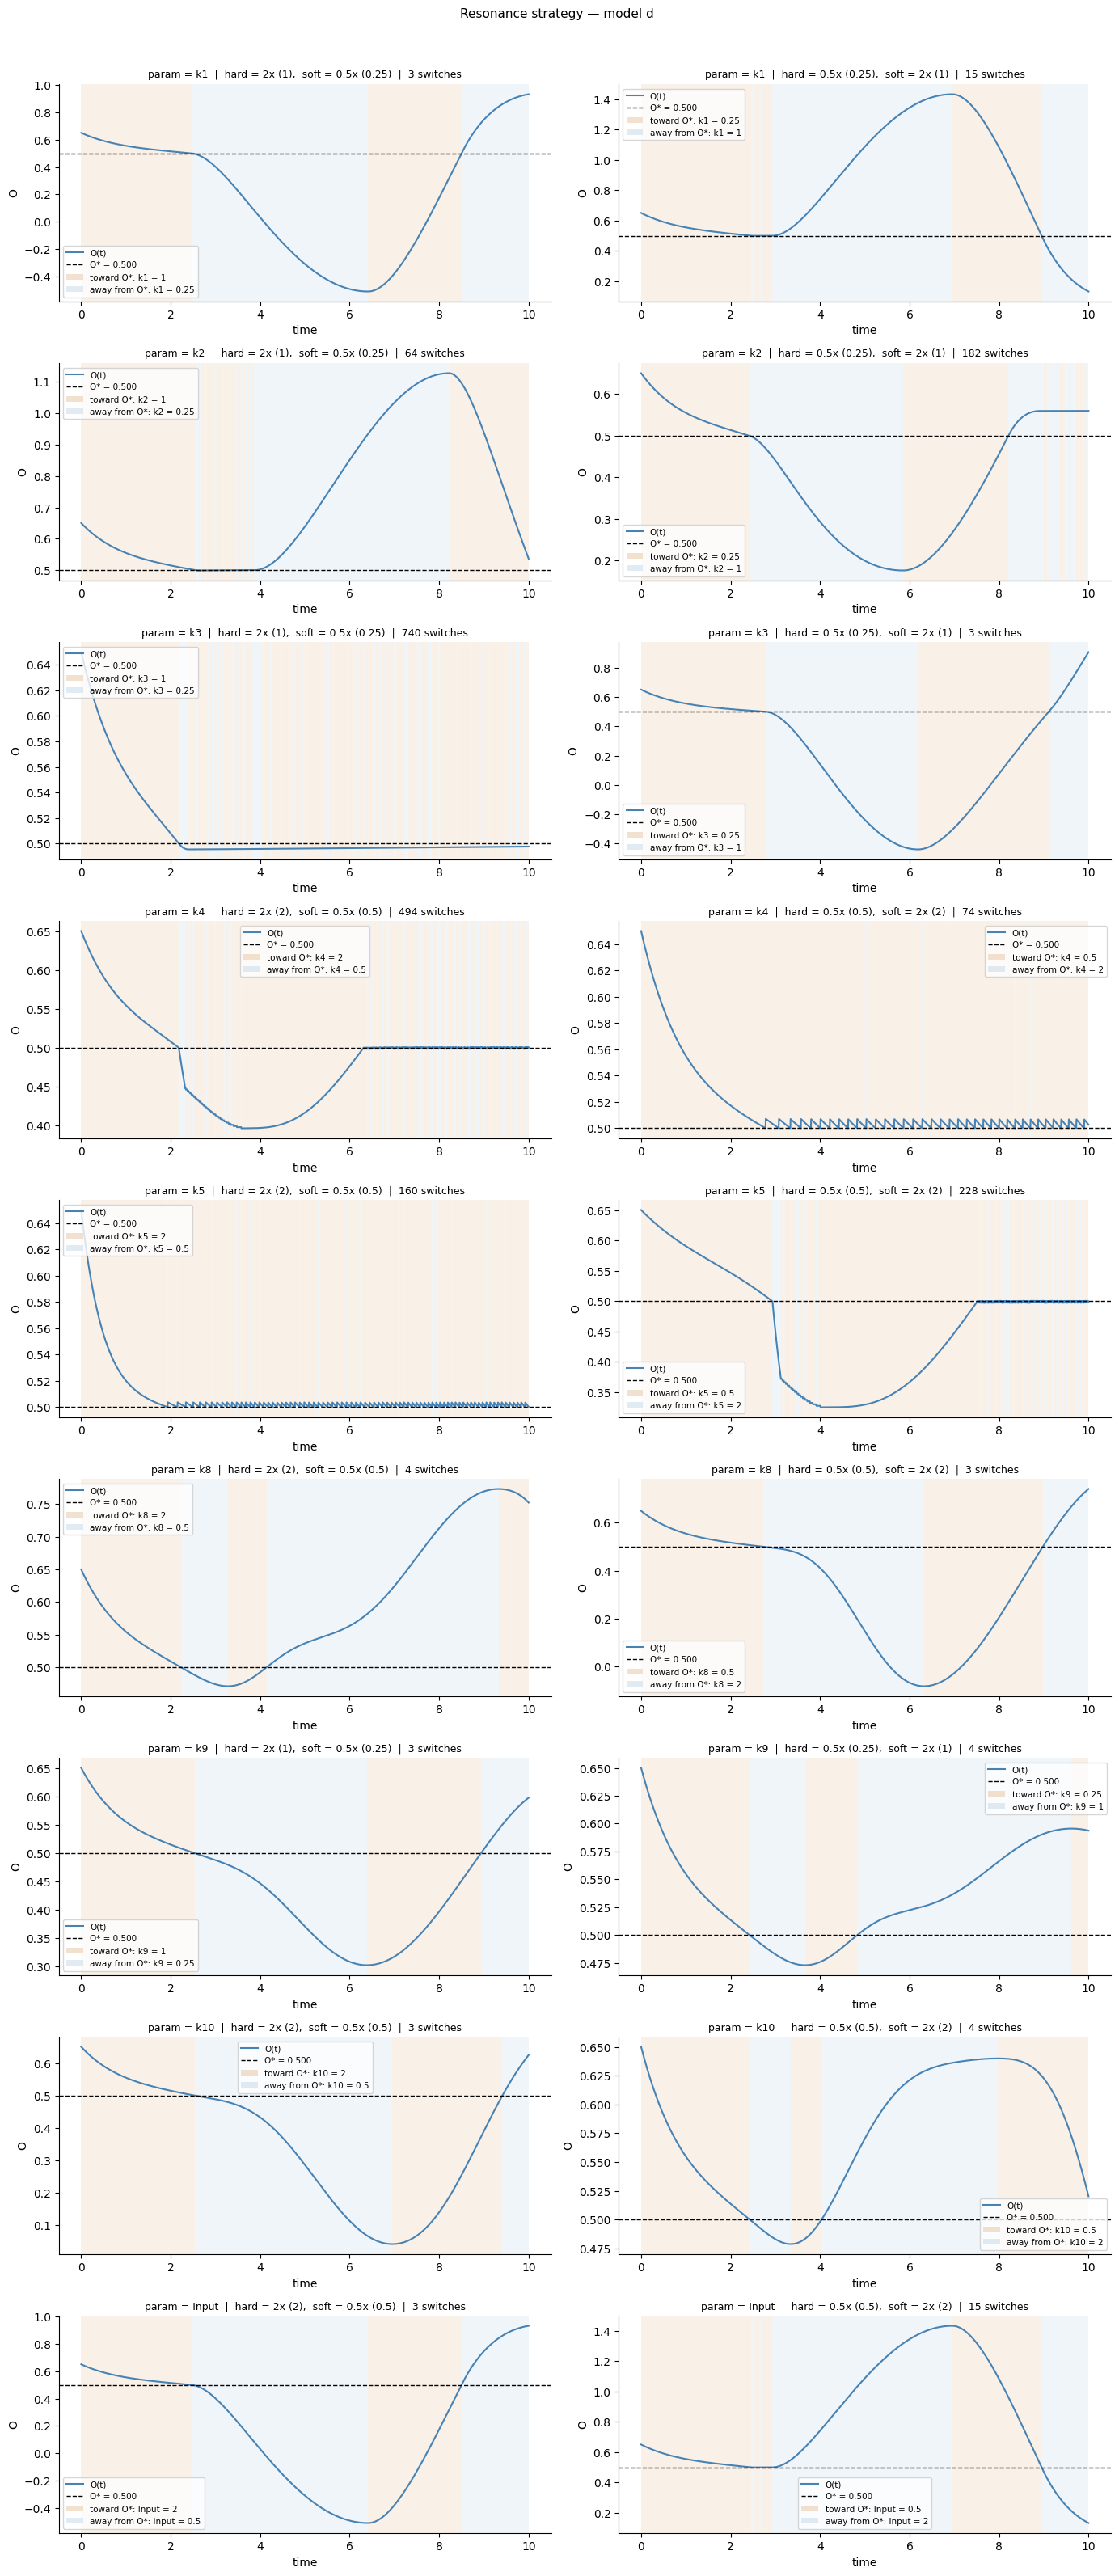

In [89]:
rs = run_resonance_demo(model_d, t_end=10)
# rs = run_resonance_demo(model_c)

## Sensitization Strategy

Sensitization strategy for an RPA model. For each RPA parameter, two variants are created (2× and 0.5× baseline).
- Preparation / Addiction Stage: We gradually give the reverse treatment, to make the system accomodated to it
- Treatment Stage: We abruptly stop the reverse treatment and switch to the original treatment

In [ ]:
class SensitizationStrategy:
    """
    Two-stage sensitization + treatment strategy for an RPAModel.

    Stage 1 — sensitization: linearly ramp the parameter from its baseline
              value to a primed value over ramp_duration time units.
    Stage 2 — treatment: abruptly switch the parameter to the treatment value
              and simulate for t_post time units.

    A control trajectory is also computed: the system holds at the baseline SS
    for the entire ramp phase (no sensitization), then receives the same
    abrupt treatment at the same time.

    Two variants per RPA parameter:
        'up_down': baseline → 2× (slow ramp),  then → 0.5× (abrupt)
        'down_up': baseline → 0.5× (slow ramp), then → 2× (abrupt)

    Results dict keys
    -----------------
    t, y          : time array and sensitized state trajectory
    y_ctrl        : control trajectory (no ramp, direct treatment)
    param_val     : parameter value at every time point (sensitized path)
    base_val, primed_val, treatment_val, ramp_duration, O_star
    """

    def __init__(self, model):
        self.model    = model
        self.baseline = dict(model.params_base)
        self._oidx    = model.output_idx
        self.O_star   = float(self._eval_ss()[self._oidx])
        self.results  = {}

    def _eval_ss(self, overrides=None):
        p = dict(self.baseline)
        if overrides:
            p.update(overrides)
        subs = {sym: p[name]
                for name, sym in zip(self.model._param_names, self.model._sym_params)}
        subs[self.model._sym_input] = p['Input']
        return np.array([float(self.model._ss_dict[s].subs(subs))
                         for s in self.model._sym_state])

    def simulate(self, param, variant='up_down', ramp_duration=10.0,
                 t_post=10.0, dt=0.005, fast_prep=False,
                 start_from_primed_ss=False):
        """
        Simulate one (param, variant) pair plus a no-ramp control.

        variant : 'up_down' (ramp 1×→2×, treat 0.5×) or
                  'down_up' (ramp 1×→0.5×, treat 2×)
        """
        base_val = self.baseline[param]
        _pos  = getattr(self.model, 'rpa_params_pos',  [])
        _neg  = getattr(self.model, 'rpa_params_neg',  [])
        if param in _pos:
            # pos: increasing param raises O
            if variant == 'up_down':
                primed_val, treatment_val = base_val * 2.0, base_val * 0.5
            else:
                primed_val, treatment_val = base_val * 0.5, base_val * 2.0
        elif param in _neg:
            # neg: decreasing param raises O
            if variant == 'up_down':
                primed_val, treatment_val = base_val * 0.5, base_val * 2.0
            else:
                primed_val, treatment_val = base_val * 2.0, base_val * 0.5
        else:
            # none/unknown: fall back to original convention
            if variant == 'up_down':
                primed_val, treatment_val = base_val * 2.0, base_val * 0.5
            else:
                primed_val, treatment_val = base_val * 0.5, base_val * 2.0

        n_ramp  = int(round(ramp_duration / dt))
        n_post  = int(round(t_post / dt))
        n_total = n_ramp + n_post

        t_arr  = np.linspace(0, ramp_duration + t_post, n_total + 1)
        y_arr  = np.zeros((len(self.model.state_vars), n_total + 1))
        y_ctrl = np.zeros_like(y_arr)
        p_arr  = np.zeros(n_total + 1)

        ss_base = self._eval_ss()
        if getattr(self.model, '_extra_vars', None):
            n_base = len(self.model.state_vars) - len(self.model._extra_vars)
            ss_base[n_base:] = 1.0

        if start_from_primed_ss:
            _override = {'Input': primed_val} if param == 'u' else {param: primed_val}
            ss_sens = self._eval_ss(_override)
            if getattr(self.model, '_extra_vars', None):
                ss_sens[n_base:] = 1.0
        else:
            ss_sens = ss_base

        y_arr[:, 0]  = ss_sens
        y_ctrl[:, 0] = ss_base
        p_arr[0]     = base_val

        ramp_vals = np.linspace(base_val, primed_val, n_ramp + 1)
        f_treat   = self.model.get_f({param: treatment_val})
        f_base    = self.model.get_f({param: base_val})
        f_primed  = self.model.get_f({param: primed_val})

        # ── Stage 1: sensitized ramp (or fast step)  /  control at baseline ──
        for i in range(n_ramp):
            if fast_prep:
                p_i   = primed_val
                f_cur = f_primed
            else:
                p_i   = ramp_vals[i]
                f_cur = self.model.get_f({param: p_i})
            p_arr[i] = p_i
            t_i      = t_arr[i]

            y_i  = y_arr[:, i]
            k1 = np.array(f_cur(t_i,           y_i))
            k2 = np.array(f_cur(t_i + 0.5*dt,  y_i + 0.5*dt*k1))
            k3 = np.array(f_cur(t_i + 0.5*dt,  y_i + 0.5*dt*k2))
            k4 = np.array(f_cur(t_i + dt,       y_i +      dt*k3))
            y_arr[:, i+1] = y_i + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

            yc_i = y_ctrl[:, i]
            c1 = np.array(f_base(t_i,           yc_i))
            c2 = np.array(f_base(t_i + 0.5*dt,  yc_i + 0.5*dt*c1))
            c3 = np.array(f_base(t_i + 0.5*dt,  yc_i + 0.5*dt*c2))
            c4 = np.array(f_base(t_i + dt,       yc_i +      dt*c3))
            y_ctrl[:, i+1] = yc_i + (dt / 6.0) * (c1 + 2*c2 + 2*c3 + c4)

        # ── Stage 2: both receive the abrupt treatment ─────────────────────
        for i in range(n_ramp, n_total):
            p_arr[i] = treatment_val
            for y_cur_arr in (y_arr, y_ctrl):
                y_i, t_i = y_cur_arr[:, i], t_arr[i]
                k1 = np.array(f_treat(t_i,           y_i))
                k2 = np.array(f_treat(t_i + 0.5*dt,  y_i + 0.5*dt*k1))
                k3 = np.array(f_treat(t_i + 0.5*dt,  y_i + 0.5*dt*k2))
                k4 = np.array(f_treat(t_i + dt,       y_i +      dt*k3))
                y_cur_arr[:, i+1] = y_i + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

        p_arr[n_ramp] = treatment_val
        p_arr[-1]     = treatment_val

        self.results.setdefault(param, {})[variant] = {
            't':             t_arr,
            'y':             y_arr,
            'y_ctrl':        y_ctrl,
            'param_val':     p_arr,
            'base_val':      base_val,
            'primed_val':    primed_val,
            'treatment_val': treatment_val,
            'ramp_duration': ramp_duration,
            'fast_prep':     fast_prep,
            'O_star':        self.O_star,
        }
        return t_arr, y_arr

    def simulate_all(self, variant='auto', start_from_primed_ss=False, **kwargs):
        kwargs['start_from_primed_ss'] = start_from_primed_ss
        v_use = 'up_down' if variant != 'down_up' else 'down_up'
        for param in self.model.rpa_params:
            print(f"  param={param}  variant={v_use} ...")
            self.simulate(param, variant=v_use, **kwargs)
        print("Done.")


def run_sensitization_demo(model, ramp_duration=10.0, t_post=30.0, dt=0.005,
                           cancer_threshold=2.0, fast_prep=False, variant='auto',
                           start_from_primed_ss=False):
    import matplotlib.patches as mpatches
    """
    Build a SensitizationStrategy for `model`, simulate both variants for
    every RPA parameter, and plot results.

    Each panel shows O(t), Cancer(t) (if present), and the parameter
    trajectory, overlaying sensitized vs no-ramp control.
    """
    ss = SensitizationStrategy(model)
    print(f"Model {model.name}  |  O* = {ss.O_star:.4f}  |  "
          f"RPA params: {model.rpa_params}\n")
    ss.simulate_all(ramp_duration=ramp_duration, t_post=t_post, dt=dt,
                fast_prep=fast_prep, variant=variant,
                start_from_primed_ss=start_from_primed_ss)

    RAMP_COLOR  = 'white'
    TREAT_COLOR = 'lightgray'

    has_cancer  = 'Cancer' in model.state_vars
    cancer_idx  = model.state_vars.index('Cancer') if has_cancer else None
    other_vars  = [(i, nm) for i, nm in enumerate(model.state_vars)
                   if i != model.output_idx and nm != 'Cancer']
    n_other     = len(other_vars)
    n_inner     = 1 + n_other + (1 if has_cancer else 0) + 1
    h_ratios    = [2] * (1 + n_other) + ([2] if has_cancer else []) + [1]

    v_use = 'up_down' if variant != 'down_up' else 'down_up'
    variants_to_show = (v_use,)
    n = len(model.rpa_params)
    fig = plt.figure(figsize=(8, 7 * n))
    outer = fig.add_gridspec(n, 1, hspace=0.45)

    for row, param in enumerate(model.rpa_params):
        for col, v in enumerate(variants_to_show):
            res  = ss.results[param][v]
            t    = res['t']
            y    = res['y']
            yc   = res['y_ctrl']
            p    = res['param_val']
            t_sw = res['ramp_duration']
            oidx = model.output_idx

            inner = outer[row, col].subgridspec(n_inner, 1, height_ratios=h_ratios,
                                                hspace=0.08)
            ax_O      = fig.add_subplot(inner[0])
            ax_others = [fig.add_subplot(inner[1 + i], sharex=ax_O)
                         for i in range(n_other)]
            ax_C      = fig.add_subplot(inner[1 + n_other], sharex=ax_O) if has_cancer else None
            ax_p      = fig.add_subplot(inner[-1], sharex=ax_O)

            active_axes = [ax_O] + ax_others + ([ax_C] if ax_C else []) + [ax_p]
            for ax in active_axes:
                ax.axvspan(t[0], t_sw,  color=RAMP_COLOR,  alpha=0.4, lw=0)
                ax.axvspan(t_sw, t[-1], color=TREAT_COLOR, alpha=0.4, lw=0)
                ax.axvline(t_sw, color='k', ls=':', lw=0.9, alpha=0.6)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

            # mark: ★ for classified params, blank for none
            _p = getattr(model, 'rpa_params_pos', None)
            _n = getattr(model, 'rpa_params_neg', None)
            if _p is not None:
                is_correct = param in (_p or []) or param in (_n or [])
            else:
                is_correct = True
            mark = '  ★' if is_correct else '  (none)'

            # ── O(t) ──────────────────────────────────────────────────────
            ax_O.plot(t, y[oidx],  color='steelblue', lw=1.8)
            ax_O.plot(t, yc[oidx], color='tomato',    lw=1.8, ls='--')
            ax_O.axhline(res['O_star'], color='k', ls='--', lw=1)
            ax_O.set_ylabel('O(t)')
            ax_O.legend(handles=[
                plt.Line2D([0], [0], color='steelblue', lw=1.8,
                           label='sensitized'),
                plt.Line2D([0], [0], color='tomato', lw=1.8, ls='--',
                           label='no ramp (control)'),
                plt.Line2D([0], [0], color='k', ls='--', lw=1,
                           label=f"O* = {res['O_star']:.3f}"),
                mpatches.Patch(facecolor=RAMP_COLOR, alpha=0.6,
                               label=(f"step → {res['primed_val']:.3g}" if res.get('fast_prep') else f"ramp → {res['primed_val']:.3g}")),
                mpatches.Patch(facecolor=TREAT_COLOR, alpha=0.6,
                               label=f"treat → {res['treatment_val']:.3g}"),
            ], fontsize=7.5, loc='upper right')
            ax_O.set_title(
                f"param = {param}  |  {v.replace('_', '→')}  "
                f"({res['base_val']:.3g} → {res['primed_val']:.3g} → "
                f"{res['treatment_val']:.3g})" + mark,
                fontsize=9,
                color='#1a7a1a' if is_correct else '#888888')
            plt.setp(ax_O.get_xticklabels(), visible=False)

            # ── Other state variables ─────────────────────────────────────
            for ax_v, (vi, vname) in zip(ax_others, other_vars):
                ax_v.plot(t, y[vi],  color='steelblue', lw=1.8)
                ax_v.plot(t, yc[vi], color='tomato',    lw=1.8, ls='--')
                ax_v.set_ylabel(vname)
                plt.setp(ax_v.get_xticklabels(), visible=False)

            # ── Cancer(t) + metrics ──────────────────────────────────────
            if has_cancer:
                c_sens = y[cancer_idx]
                c_ctrl = yc[cancer_idx]

                # ── metric 1: min-Cancer ratio over treatment phase ────────
                n_treat  = np.searchsorted(t, t_sw, side='right')
                min_sens = c_sens[n_treat:].min()
                min_ctrl = c_ctrl[n_treat:].min()
                ratio    = min_sens / min_ctrl if min_ctrl != 0 else float('nan')

                # ── metric 2: time to progression ─────────────────────────
                def ttp(cancer_traj):
                    cross = np.where(cancer_traj > cancer_threshold)[0]
                    return t[cross[0]] if len(cross) else float('inf')

                ttp_s = ttp(c_sens)
                ttp_c = ttp(c_ctrl)

                # ── plot ──────────────────────────────────────────────────
                ax_C.plot(t, c_sens, color='steelblue', lw=1.8)
                ax_C.plot(t, c_ctrl, color='tomato',    lw=1.8, ls='--')
                ax_C.axhline(cancer_threshold, color='k', ls=':', lw=0.9, alpha=0.6)
                if np.isfinite(ttp_s):
                    ax_C.axvline(ttp_s, color='steelblue', ls=':', lw=1.2, alpha=0.8)
                if np.isfinite(ttp_c):
                    ax_C.axvline(ttp_c, color='tomato',    ls=':', lw=1.2, alpha=0.8)
                ax_C.set_ylabel('Cancer')

                ttp_s_str = '%.1f' % ttp_s if np.isfinite(ttp_s) else 'never'
                ttp_c_str = '%.1f' % ttp_c if np.isfinite(ttp_c) else 'never'
                stats = ('min ratio (s/c): %.3f\n'
                         'TTP sensitized: %s\n'
                         'TTP control:    %s') % (ratio, ttp_s_str, ttp_c_str)
                ax_C.text(0.97, 0.97, stats, transform=ax_C.transAxes,
                          fontsize=7.5, ha='right', va='top', family='monospace',
                          bbox=dict(facecolor='white', alpha=0.75, edgecolor='none',
                                    boxstyle='round,pad=0.3'))
                plt.setp(ax_C.get_xticklabels(), visible=False)

            # ── parameter(t) ──────────────────────────────────────────────
            p_ctrl = np.where(t <= t_sw, res['base_val'], res['treatment_val'])
            ax_p.plot(t, p,      color='steelblue', lw=1.5)
            ax_p.plot(t, p_ctrl, color='tomato',    lw=1.5, ls='--')
            ax_p.set_ylabel(param)
            ax_p.set_xlabel('time')
            yticks = sorted({res['base_val'], res['primed_val'], res['treatment_val']})
            ax_p.set_yticks(yticks)
            ax_p.set_yticklabels([f"{v:.3g}" for v in yticks], fontsize=7)

    fig.suptitle(f'Sensitization strategy — model {model.name}', fontsize=11)
    plt.show()

    # ── Bar plots: correct-variant metrics per RPA parameter ─────────
    INF_CAP = np.log2(20)
    if has_cancer:
        bar_params, lfc_cancer, lfc_ttp, lfc_O, lfc_O_is_inf, bar_variants = [], [], [], [], [], []

        for param in model.rpa_params:
            for v in variants_to_show:
                res  = ss.results[param][v]
                t_r  = res['t']
                y_r  = res['y']
                yc_r = res['y_ctrl']
                t_sw = res['ramp_duration']
                n_rp = np.searchsorted(t_r, t_sw, side='right')

                c_s = y_r[cancer_idx, n_rp:]
                c_c = yc_r[cancer_idx, n_rp:]
                o_s = y_r[model.output_idx, n_rp:]
                o_c = yc_r[model.output_idx, n_rp:]

                # Cancer lfc: max+sens/ctrl for up_down, min+ctrl/sens for down_up
                if v == 'up_down':
                    ext_cs, ext_cc = c_s.min(), c_c.min()
                    lfc_c = np.log2(ext_cs / ext_cc) if ext_cc > 0 and ext_cs > 0 else np.nan
                else:
                    ext_cs, ext_cc = c_s.max(), c_c.max()
                    lfc_c = np.log2(ext_cc / ext_cs) if ext_cc > 0 and ext_cs > 0 else np.nan

                # TTP lfc
                def _ttp(traj, _t=t_r[n_rp:]):
                    cross = np.where(traj > cancer_threshold)[0]
                    return _t[cross[0]] if len(cross) else float('inf')

                ttp_s = _ttp(c_s)
                ttp_c = _ttp(c_c)
                if   np.isfinite(ttp_s) and np.isfinite(ttp_c) and ttp_c > 0:
                    lfc_t = np.log2(ttp_s / ttp_c)
                elif not np.isfinite(ttp_s) and np.isfinite(ttp_c):
                    lfc_t = INF_CAP
                elif np.isfinite(ttp_s) and not np.isfinite(ttp_c):
                    lfc_t = -INF_CAP
                else:
                    lfc_t = np.nan

                # O lfc: max+sens/ctrl for up_down, min+ctrl/sens for down_up
                if v == 'up_down':
                    ext_os, ext_oc = o_s.min(), o_c.min()
                    if ext_oc <= 0 and ext_os > 0:
                        lfc_o, inf_o = INF_CAP, True
                    elif ext_os > 0 and ext_oc > 0:
                        lfc_o, inf_o = np.log2(ext_os / ext_oc), False
                    else:
                        lfc_o, inf_o = np.nan, False
                else:
                    ext_os, ext_oc = o_s.max(), o_c.max()
                    if ext_os <= 0 and ext_oc > 0:
                        lfc_o, inf_o = INF_CAP, True
                    elif ext_oc > 0 and ext_os > 0:
                        lfc_o, inf_o = np.log2(ext_oc / ext_os), False
                    else:
                        lfc_o, inf_o = np.nan, False

                bar_params.append(param)
                bar_variants.append(v)
                lfc_cancer.append(lfc_c)
                lfc_ttp.append(lfc_t)
                lfc_O.append(lfc_o)
                lfc_O_is_inf.append(inf_o)
                break                            # found correct variant

        if bar_params:
            x = np.arange(len(bar_params))
            w = max(6, 2.2 * len(bar_params))
            fig2, (ax_r, ax_t, ax_o) = plt.subplots(1, 3, figsize=(w * 1.5, 4))

            # ── min Cancer lfc ────────────────────────────────────────────
            colors_r = ['#d7e5c5' if v > 0 else '#f6ceca' for v in lfc_cancer]
            ax_r.bar(x, lfc_cancer, color=colors_r, edgecolor='k', linewidth=0.6)
            ax_r.axhline(0, color='k', lw=1)
            ax_r.set_xticks(x); ax_r.set_xticklabels(bar_params, fontsize=9)
            _vnt0 = bar_variants[0] if bar_variants else 'up_down'
            _c_lbl = 'min Cancer (c/s)' if _vnt0 == 'up_down' else 'max Cancer (c/s)'
            _o_lbl = 'min output O (c/s)' if _vnt0 == 'up_down' else 'max output O (s/c)'
            ax_r.set_ylabel('log₂ fold-change')
            ax_r.set_title(_c_lbl + chr(10) + '(> 0 = helps)', fontsize=9)
            ax_r.spines['top'].set_visible(False); ax_r.spines['right'].set_visible(False)

            # ── TTP lfc ───────────────────────────────────────────────────
            colors_t = ['#d7e5c5' if (not np.isnan(v) and v > 0) else '#f6ceca'
                        for v in lfc_ttp]
            ax_t.bar(x, lfc_ttp, color=colors_t, edgecolor='k', linewidth=0.6)
            ax_t.axhline(0, color='k', lw=1)
            for xi, v in zip(x, lfc_ttp):
                if np.isfinite(v) and abs(v) >= INF_CAP * 0.95:
                    ax_t.text(xi, v + 0.05 * np.sign(v), '∞',
                              ha='center', va='bottom' if v > 0 else 'top', fontsize=9)
            ax_t.set_xticks(x); ax_t.set_xticklabels(bar_params, fontsize=9)
            ax_t.set_ylabel('log₂ fold-change  (sens / ctrl)')
            ax_t.set_title('TTP' + chr(10) + '(> 0 = helps)', fontsize=9)
            ax_t.spines['top'].set_visible(False); ax_t.spines['right'].set_visible(False)

            # ── min output O lfc ──────────────────────────────────────────
            lfc_O_disp = [np.clip(v, -INF_CAP, INF_CAP) for v in lfc_O]
            colors_o = ['#d7e5c5' if v > 0 else '#f6ceca' for v in lfc_O_disp]
            ax_o.bar(x, lfc_O_disp, color=colors_o, edgecolor='k', linewidth=0.6)
            ax_o.axhline(0, color='k', lw=1)
            for xi, v_disp, v_raw, is_inf in zip(x, lfc_O_disp, lfc_O, lfc_O_is_inf):
                if is_inf:
                    ax_o.text(xi, v_disp + 0.05 * np.sign(v_disp), '∞',
                              ha='center', va='bottom' if v_disp > 0 else 'top', fontsize=9)
                elif np.isfinite(v_raw) and abs(v_raw) > abs(v_disp) * 1.01:
                    ax_o.text(xi, v_disp + 0.05 * np.sign(v_disp),
                              f'▲{v_raw:.1f}',
                              ha='center', va='bottom' if v_disp > 0 else 'top', fontsize=8)
            ax_o.set_xticks(x); ax_o.set_xticklabels(bar_params, fontsize=9)
            ax_o.set_ylabel('log₂ fold-change')
            ax_o.set_title(_o_lbl + chr(10) + '(> 0 = helps)', fontsize=9)
            ax_o.spines['top'].set_visible(False); ax_o.spines['right'].set_visible(False)

            fig2.suptitle('Sensitization metrics — model ' + model.name +
                          '  (correct variant only)', fontsize=10)
            plt.tight_layout()
            plt.show()

    return ss


Model a:
  pos  (O↑): ['k1', 'Input']
  neg  (O↓): ['k2', 'k3']
  none (O~): []
Model b:
  pos  (O↑): ['k1', 'k5', 'Input']
  neg  (O↓): ['k2', 'k7']
  none (O~): []
Model c:
  pos  (O↑): ['k1', 'k9', 'Input']
  neg  (O↓): ['k2', 'k3', 'k10', 'k11']
  none (O~): []
Model d:
  pos  (O↑): ['k1', 'k4', 'k9', 'k10', 'Input']
  neg  (O↓): ['k2', 'k3', 'k5', 'k8']
  none (O~): []
Model e:
  pos  (O↑): ['k1', 'k6', 'Input']
  neg  (O↓): ['k2', 'k7', 'k8']
  none (O~): []
Model f:
  pos  (O↑): ['k1', 'k6', 'k13', 'Input']
  neg  (O↓): ['k2', 'k3', 'k8', 'k12']
  none (O~): ['k7', 'k11']


/tmp/ipykernel_251717/3891464685.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


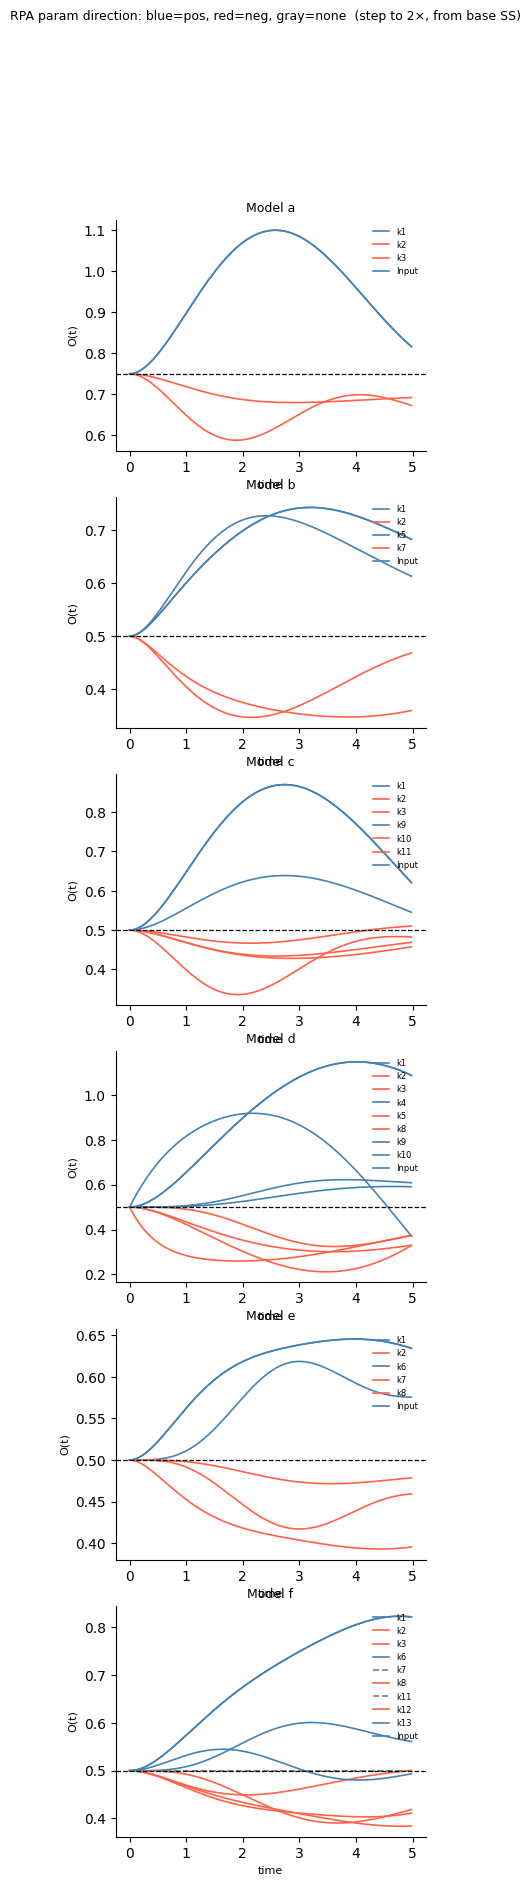

In [130]:
# ── RPA parameter direction classification ────────────────────────────────────
# For each RPA parameter: step it to 2× baseline, simulate the transient from
# base SS, and classify the output O response as positively correlated (O rises
# above O*), negatively correlated (O drops below O*), or no effect.
# Results are stored on each model object as rpa_params_pos / neg / none.

from scipy.integrate import solve_ivp as _siv

T_STEP   = 5.0
DT_STEP  = 0.02
TOL      = 0.005   # fraction of O* — changes smaller than this are "none"

n_models = len(ALL_MODELS)
fig, axes = plt.subplots(n_models, 1, figsize=(4, 3.5 * n_models),
                         sharey=False, gridspec_kw={'wspace': 0.35})
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, ALL_MODELS):
    # ── base SS ───────────────────────────────────────────────────────────────
    ss_obj   = SensitizationStrategy(model)
    O_star   = ss_obj.O_star
    ss_base  = ss_obj._eval_ss()
    if getattr(model, '_extra_vars', None):
        n_base = len(model.state_vars) - len(model._extra_vars)
        ss_base[n_base:] = 1.0

    pos_params, neg_params, none_params = [], [], []
    t_eval = np.arange(0, T_STEP, DT_STEP)

    for param in model.rpa_params:
        f_step = model.get_f({param: model.params_base[param] * 2.0})
        sol = _siv(f_step, (0, T_STEP), ss_base, t_eval=t_eval,
                   method='Radau', rtol=1e-8, atol=1e-10)
        O_traj = sol.y[model.output_idx]
        O_mean = O_traj.mean()

        if O_mean > O_star * (1 + TOL):
            pos_params.append(param)
            color, ls = 'steelblue', '-'
        elif O_mean < O_star * (1 - TOL):
            neg_params.append(param)
            color, ls = 'tomato', '-'
        else:
            none_params.append(param)
            color, ls = 'gray', '--'

        ax.plot(sol.t, O_traj, color=color, lw=1.2, ls=ls, label=param)

    model.rpa_params_pos  = pos_params
    model.rpa_params_neg  = neg_params
    model.rpa_params_none = none_params

    ax.axhline(O_star, color='k', ls='--', lw=0.9)
    ax.set_title(f'Model {model.name}', fontsize=9)
    ax.set_xlabel('time', fontsize=8)
    ax.set_ylabel('O(t)', fontsize=8)
    ax.legend(fontsize=6, frameon=False, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    print(f'Model {model.name}:')
    print(f'  pos  (O↑): {pos_params}')
    print(f'  neg  (O↓): {neg_params}')
    print(f'  none (O~): {none_params}')

plt.suptitle('RPA param direction: blue=pos, red=neg, gray=none  (step to 2×, from base SS)',
             fontsize=9)
plt.tight_layout()
plt.show()


Model a  |  O* = 0.7500  |  RPA params: ['k1', 'k2', 'k3', 'Input']

  param=k1  variant=down_up ...
  param=k2  variant=down_up ...
  param=k3  variant=down_up ...
  param=Input  variant=down_up ...
Done.


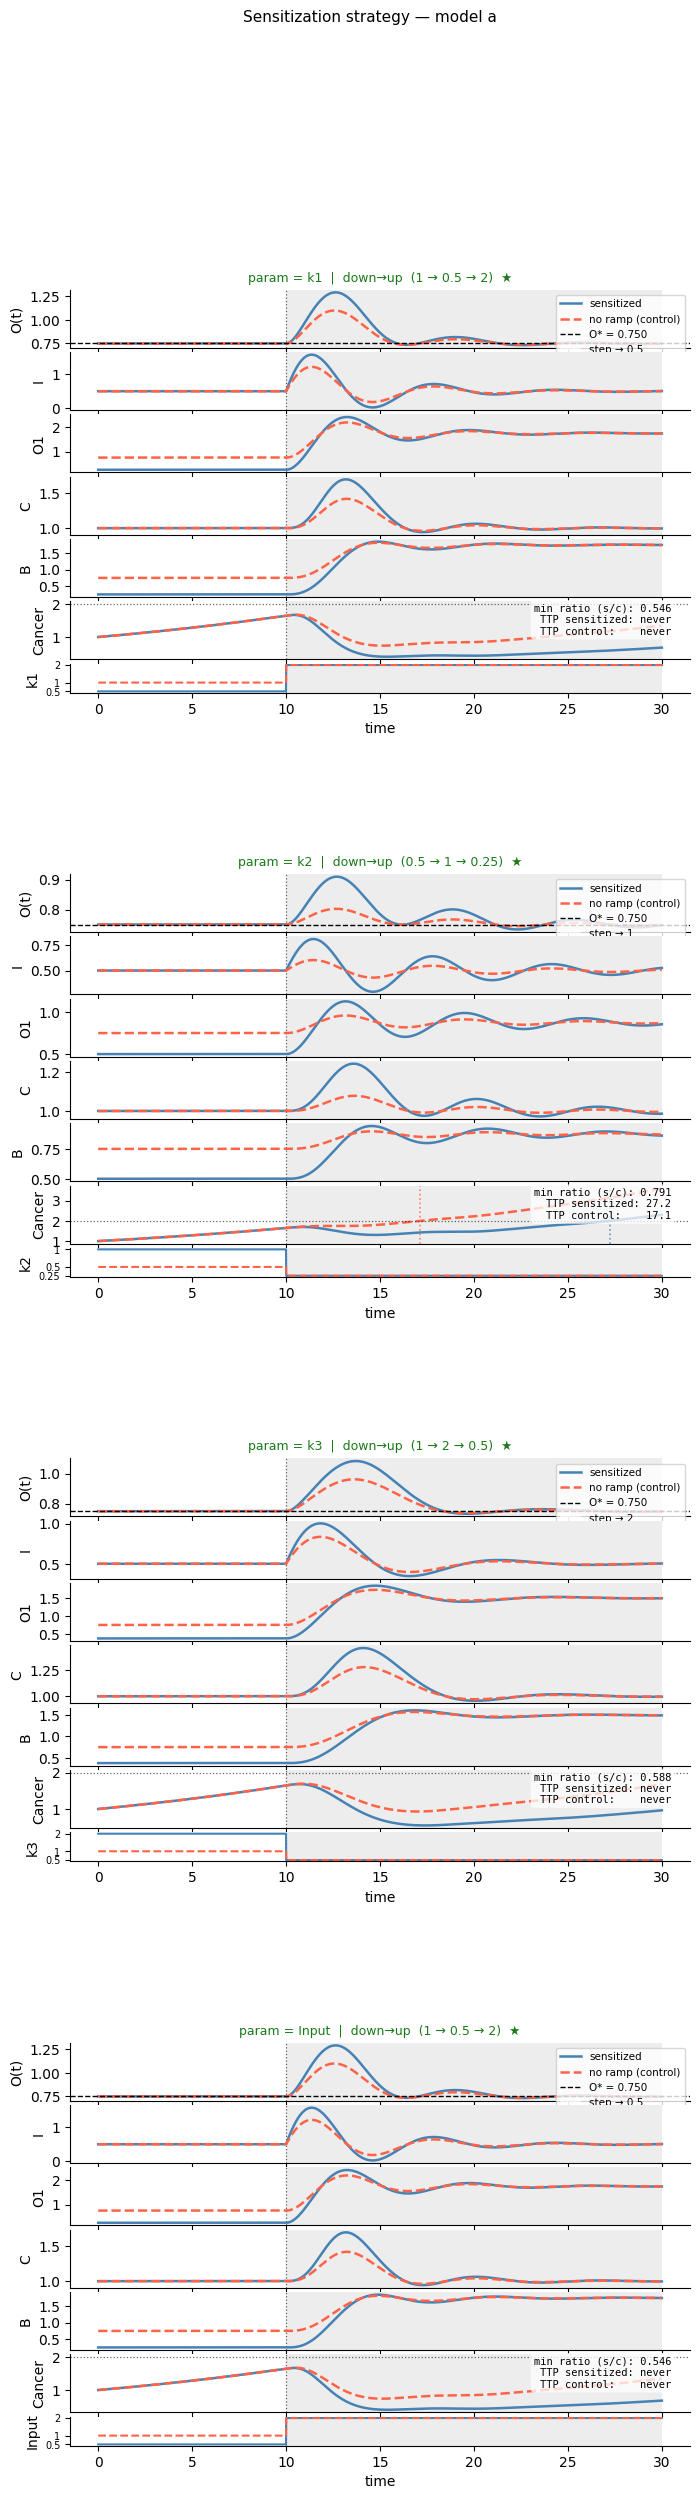

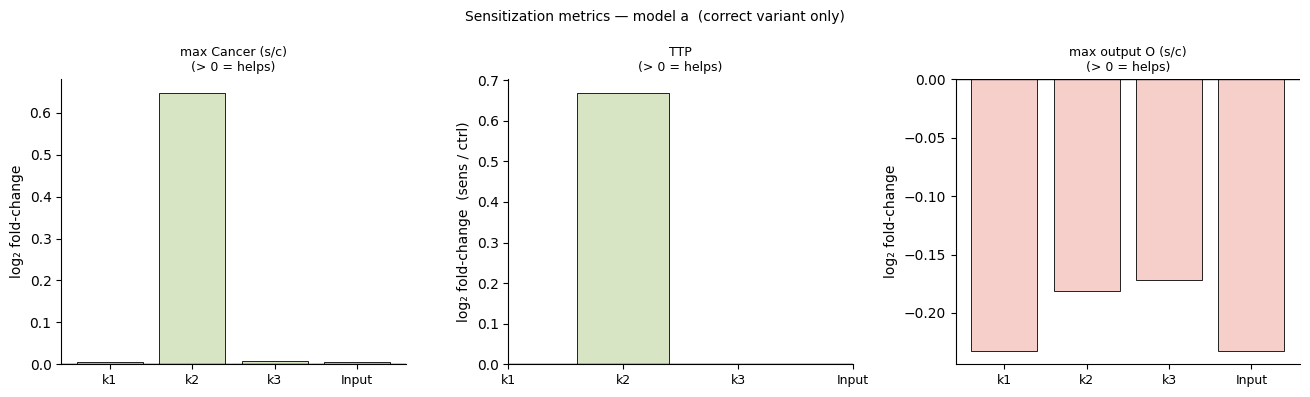

In [131]:
run_sensitization_demo(model_a, ramp_duration=10.0, t_post=20.0, cancer_threshold=2.0, fast_prep=True, start_from_primed_ss=True, variant='down_up')


In [ ]:
from rpa_control.paths import save_fig


RAMP_DURATION    = 30.0
T_POST           = 20.0
DT               = 0.005
CANCER_THRESHOLD = 2.0
VARIANT          = 'down_up'
GREEN = "#d7e5c5"
RED   = "#f6ceca"
INF_CAP = np.log2(20)

for model in ALL_MODELS:
    if "Cancer" not in model.state_vars:
        continue

    # ── run strategy ─────────────────────────────────────────────────────────
    ss = SensitizationStrategy(model)
    ss.simulate_all(ramp_duration=RAMP_DURATION, t_post=T_POST, dt=DT,
                    fast_prep=True, start_from_primed_ss=True, variant=VARIANT)

    cidx = model.state_vars.index("Cancer")
    oidx = model.output_idx

    params_out, lfc_cancer, lfc_ttp, lfc_O, lfc_O_is_inf, bar_variants = [], [], [], [], [], []

    for param in model.rpa_params:
        res             = ss.results[param][VARIANT]
        t_r, y_r, yc_r = res["t"], res["y"], res["y_ctrl"]
        t_sw            = res["ramp_duration"]
        n_rp            = np.searchsorted(t_r, t_sw, side="right")

        c_s, c_c = y_r[cidx, n_rp:], yc_r[cidx, n_rp:]
        o_s, o_c = y_r[oidx, n_rp:], yc_r[oidx, n_rp:]

        # Cancer lfc: max+s/c for up_down, min+c/s for down_up
        if VARIANT == 'up_down':
            ext_cs, ext_cc = c_s.min(), c_c.min()
            lfc_c = np.log2(ext_cc / ext_cs) if ext_cc > 0 and ext_cs > 0 else np.nan
        else:
            ext_cs, ext_cc = c_s.max(), c_c.max()
            lfc_c = np.log2(ext_cc / ext_cs) if ext_cc > 0 and ext_cs > 0 else np.nan

        # TTP lfc
        def _ttp(traj, _t=t_r[n_rp:]):
            cross = np.where(traj > CANCER_THRESHOLD)[0]
            return _t[cross[0]] if len(cross) else float("inf")

        ttp_s, ttp_c = _ttp(c_s), _ttp(c_c)
        if   np.isfinite(ttp_s) and np.isfinite(ttp_c) and ttp_c > 0:
            lfc_t = np.log2(ttp_s / ttp_c)
        elif not np.isfinite(ttp_s) and np.isfinite(ttp_c):
            lfc_t = INF_CAP
        elif np.isfinite(ttp_s) and not np.isfinite(ttp_c):
            lfc_t = -INF_CAP
        else:
            lfc_t = np.nan

        # O lfc: max+s/c for up_down, min+c/s for down_up
        if VARIANT == 'up_down':
            ext_os, ext_oc = o_s.min(), o_c.min()
            if ext_os <= 0 and ext_oc > 0:
                lfc_o, inf_o = INF_CAP, True
            elif ext_os > 0 and ext_oc > 0:
                lfc_o, inf_o = np.log2(ext_oc / ext_os), False
            else:
                lfc_o, inf_o = np.nan, False
        else:
            ext_os, ext_oc = o_s.max(), o_c.max()
            if ext_oc <= 0 and ext_os > 0:
                lfc_o, inf_o = INF_CAP, True
            elif ext_oc > 0 and ext_os > 0:
                lfc_o, inf_o = np.log2(ext_os / ext_oc), False
            else:
                lfc_o, inf_o = np.nan, False

        params_out.append(param)
        bar_variants.append(VARIANT)
        lfc_cancer.append(lfc_c)
        lfc_ttp.append(lfc_t)
        lfc_O.append(lfc_o)
        lfc_O_is_inf.append(inf_o)

    if not params_out:
        continue

    x = np.arange(len(params_out))
    w = max(4, 1.2 * len(params_out))
    _c_lbl = "min Cancer (c/s)" if VARIANT == "up_down" else "max Cancer (c/s)"
    _o_lbl = "min output O (c/s)" if VARIANT == "up_down" else "max output O (s/c)"

    # ── Plot 1: Cancer lfc ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(w, 3.5))
    colors = [GREEN if v > 0 else RED for v in lfc_cancer]
    ax.bar(x, lfc_cancer, color=colors, edgecolor="k", linewidth=0.6)
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(params_out, fontsize=9)
    ax.set_ylabel("log₂ fold-change")
    ax.set_title("Model %s  —  %s  (> 0 = helps)" % (model.name, _c_lbl))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()

    # ── Plot 2: TTP lfc ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(w, 3.5))
    colors_t = [GREEN if (not np.isnan(v) and v > 0) else RED for v in lfc_ttp]
    ax.bar(x, lfc_ttp, color=colors_t, edgecolor="k", linewidth=0.6)
    ax.axhline(0, color="k", lw=1)
    for xi, v in zip(x, lfc_ttp):
        if np.isfinite(v) and abs(v) >= INF_CAP * 0.95:
            ax.text(xi, v + 0.05 * np.sign(v), "∞", ha="center",
                    va="bottom" if v > 0 else "top", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels(params_out, fontsize=9)
    ax.set_ylabel("log₂ fold-change  (sens / ctrl)")
    ax.set_title("Model %s  —  TTP  (> 0 = helps)" % model.name.upper())
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()

    # ── Plot 3: Output O lfc ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(w, 3.5))
    lfc_O_disp = [np.clip(v, -INF_CAP, INF_CAP) for v in lfc_O]
    colors_o = [GREEN if v > 0 else RED for v in lfc_O_disp]
    ax.bar(x, lfc_O_disp, color=colors_o, edgecolor="k", linewidth=0.6)
    ax.axhline(0, color="k", lw=1)
    for xi, v_disp, v_raw, is_inf in zip(x, lfc_O_disp, lfc_O, lfc_O_is_inf):
        if is_inf:
            ax.text(xi, v_disp + 0.05 * np.sign(v_disp), "∞",
                    ha="center", va="bottom" if v_disp > 0 else "top", fontsize=9)
        elif np.isfinite(v_raw) and abs(v_raw) > abs(v_disp) * 1.01:
            ax.text(xi, v_disp + 0.05 * np.sign(v_disp), f"▲{v_raw:.1f}",
                    ha="center", va="bottom" if v_disp > 0 else "top", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(params_out, fontsize=9)
    ax.set_ylabel("log₂ fold-change")
    ax.set_title("Model %s  —  %s  (> 0 = helps)" % (model.name, _o_lbl))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()

    save_fig(fig, f"figure6_model{model.name}_output_lfc.png")


## Separation-of-Timescales Strategy

Periodic intermittent treatment whose on/off timing is chosen automatically from the system dynamics.

For each RPA parameter p two treatment variants are explored (2× and 0.5× baseline):

- **T_on** — apply constant treatment from baseline SS; T_on is the first time dO/dt changes sign (output stops its initial monotone response).
- **T_off** — apply one T_on pulse then switch off; T_off is the first time **all** homeostatic variables (every state var except O) satisfy |x_i(t) − x_i\*| / |x_i\*| ≤ 1 − recovery_frac.

These timings define a periodic schedule: n_cycles of (on for T_on, off for T_off).

Two diagnostic plots verify the heuristics before showing the full periodic simulation.

In [123]:
class SeparationOfTimescalesStrategy:
    """
    Periodic intermittent treatment for an RPAModel based on separation of timescales.

    For each RPA parameter p two variants are tried (2× and 0.5× baseline).
    Treatment timing (T_on, T_off) is determined automatically:

        T_on  — simulate constant treatment for the full t_max_ton window; T_on is
                the time at which Cancer reaches its minimum.  If Cancer never drops
                below its initial value, the (param, scale) pair is marked
                non-successful and skipped.
        T_off — apply one T_on pulse then switch off; T_off is the first time ALL
                homeostatic variables (every state var except O and Cancer) satisfy
                |x_i(t) − x_i*| / |x_i*| <= 1 − recovery_frac.

    A periodic simulation of n_cycles × (T_on on, T_off off) is then produced.

    results[param][scale] keys
    --------------------------
    success                  : bool — False when Cancer never decays under treatment
    T_on, T_off              : timing floats  (only when success=True)
    t_ton_diag, y_ton_diag  : constant-treatment diagnostic trajectory
    ton_min_i                : array index of Cancer minimum (success=True only)
    t_toff_diag, y_toff_diag : T_on pulse + recovery trajectory (success=True only)
    toff_rec_times           : per-homeostatic-var recovery times relative to
                               recovery start (success=True only)
    t_periodic, y_periodic, on_mask : periodic simulation (success=True only)
    O_star, param_val, base_val, recovery_frac
    """

    def __init__(self, model):
        self.model    = model
        self.baseline = dict(model.params_base)
        self._oidx    = model.output_idx
        # Extra vars (e.g. Cancer) excluded from homeostatic variable set
        _extra_names       = set(getattr(model, '_extra_vars', []))
        self._hidx         = [i for i in range(len(model.state_vars))
                              if i != self._oidx
                              and model.state_vars[i] not in _extra_names]
        self._cancer_idx   = next(
            (i for i, v in enumerate(model.state_vars) if v in _extra_names), None)
        self.O_star   = float(self._eval_ss()[self._oidx])
        self.results  = {}

    # ── private helpers ───────────────────────────────────────────────────────

    def _eval_ss(self, overrides=None):
        p = dict(self.baseline)
        if overrides:
            p.update(overrides)
        subs = {sym: p[name]
                for name, sym in zip(self.model._param_names, self.model._sym_params)}
        subs[self.model._sym_input] = p['Input']
        return np.array([float(self.model._ss_dict[s].subs(subs))
                         for s in self.model._sym_state])

    def _init_y0(self, overrides=None):
        """SS with extra vars (e.g. Cancer) initialized to 1.0."""
        y0 = self._eval_ss(overrides)
        m  = self.model
        if getattr(m, '_extra_vars', None):
            y0[len(m.state_vars) - len(m._extra_vars):] = 1.0
        return y0

    @staticmethod
    def _rk4_step(f, t, y, dt):
        k1 = np.array(f(t,          y))
        k2 = np.array(f(t + 0.5*dt, y + 0.5*dt*k1))
        k3 = np.array(f(t + 0.5*dt, y + 0.5*dt*k2))
        k4 = np.array(f(t + dt,     y +      dt*k3))
        return y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    def _integrate(self, f, y0, t_max, dt):
        n     = int(round(t_max / dt))
        t_arr = np.linspace(0, t_max, n + 1)
        y_arr = np.zeros((len(y0), n + 1))
        y_arr[:, 0] = y0
        for i in range(n):
            y_arr[:, i + 1] = self._rk4_step(f, t_arr[i], y_arr[:, i], dt)
        return t_arr, y_arr

    # ── heuristic timing ──────────────────────────────────────────────────────

    def find_T_on(self, param, scale_val, dt=0.005, t_max=200):
        """
        Simulate constant treatment for t_max; T_on = time of Cancer minimum.
        Returns (t_arr, y_arr, T_on, min_i, success).
        success=False when Cancer never drops below its initial value.
        """
        y0  = self._init_y0()
        f   = self.model.get_f({param: scale_val})
        t_arr, y_arr = self._integrate(f, y0, t_max, dt)

        cidx        = self._cancer_idx
        cancer      = y_arr[cidx]
        cancer_init = cancer[0]
        min_i       = int(np.argmin(cancer))

        if cancer[min_i] >= cancer_init:
            return t_arr, y_arr, None, None, False

        return t_arr, y_arr, float(t_arr[min_i]), min_i, True

    def find_T_off(self, param, scale_val, T_on, recovery_frac=0.9,
                   dt=0.005, t_max=500):
        """
        Apply T_on pulse then switch off; T_off is the first time ALL homeostatic
        variables (state vars except O and Cancer) satisfy
        |x_i(t) − x_i*| / |x_i*| <= 1 − recovery_frac.
        Returns (t_combined, y_combined, rec_times, T_off).
        """
        y0_ss   = self._init_y0()
        f_treat = self.model.get_f({param: scale_val})
        f_base  = self.model.get_f()

        t_on_arr, y_on = self._integrate(f_treat, y0_ss, T_on, dt)
        t_rec,    y_rec = self._integrate(f_base, y_on[:, -1], t_max, dt)

        hidx      = self._hidx
        ss_h      = y0_ss[hidx]
        threshold = 1.0 - recovery_frac
        rec_times = np.full(len(hidx), np.nan)

        for k, hi in enumerate(hidx):
            rel_err = np.abs(y_rec[hi] - ss_h[k]) / (np.abs(ss_h[k]) + 1e-12)
            cross   = np.where(rel_err <= threshold)[0]
            if len(cross):
                rec_times[k] = float(t_rec[cross[0]])

        T_off  = float(np.nanmax(rec_times)) if not np.all(np.isnan(rec_times)) else t_max
        t_comb = np.concatenate([t_on_arr, t_rec[1:] + T_on])
        y_comb = np.concatenate([y_on, y_rec[:, 1:]], axis=1)

        return t_comb, y_comb, rec_times, T_off

    # ── simulation ────────────────────────────────────────────────────────────

    def simulate(self, param, scale='2x', n_cycles=5, recovery_frac=0.9,
                 dt=0.005, t_max_ton=200, t_max_toff=500):
        """Determine T_on / T_off and simulate periodic treatment."""
        base_val  = self.baseline[param]
        scale_val = base_val * (2.0 if scale == '2x' else 0.5)

        t_ton, y_ton, T_on, min_i, success = self.find_T_on(
            param, scale_val, dt=dt, t_max=t_max_ton)

        if not success:
            self.results.setdefault(param, {})[scale] = dict(
                success=False,
                t_ton_diag=t_ton, y_ton_diag=y_ton,
                O_star=self.O_star, param_val=scale_val, base_val=base_val,
            )
            return None, None

        t_toff, y_toff, rec_times, T_off = self.find_T_off(
            param, scale_val, T_on, recovery_frac=recovery_frac,
            dt=dt, t_max=t_max_toff)

        f_treat = self.model.get_f({param: scale_val})
        f_base  = self.model.get_f()
        n_on    = int(round(T_on  / dt))
        n_off   = int(round(T_off / dt))
        n_total = n_cycles * (n_on + n_off)

        y0      = self._init_y0()
        t_per   = np.zeros(n_total + 1)
        y_per   = np.zeros((len(y0), n_total + 1))
        on_mask = np.zeros(n_total + 1, dtype=bool)
        y_per[:, 0] = y0

        step  = 0
        t_cur = 0.0
        for _ in range(n_cycles):
            for f_cur, is_on, n_phase in [
                (f_treat, True,  n_on),
                (f_base,  False, n_off),
            ]:
                for _ in range(n_phase):
                    on_mask[step]      = is_on
                    y_per[:, step + 1] = self._rk4_step(f_cur, t_cur, y_per[:, step], dt)
                    t_cur             += dt
                    t_per[step + 1]    = t_cur
                    step              += 1
        on_mask[step] = on_mask[step - 1]

        self.results.setdefault(param, {})[scale] = dict(
            success=True,
            T_on=T_on, T_off=T_off,
            t_ton_diag=t_ton, y_ton_diag=y_ton, ton_min_i=min_i,
            t_toff_diag=t_toff, y_toff_diag=y_toff, toff_rec_times=rec_times,
            recovery_frac=recovery_frac,
            t_periodic=t_per[:step + 1], y_periodic=y_per[:, :step + 1],
            on_mask=on_mask[:step + 1],
            O_star=self.O_star, param_val=scale_val, base_val=base_val,
        )
        return T_on, T_off

    def simulate_all(self, **kwargs):
        for param in self.model.rpa_params:
            for scale in ('2x', '0.5x'):
                print(f"  param={param}  scale={scale} ...")
                T_on, T_off = self.simulate(param, scale=scale, **kwargs)
                if T_on is None:
                    print(f"    → non-successful (Cancer does not decay)")
                else:
                    print(f"    T_on = {T_on:.3f},  T_off = {T_off:.3f}")
        print("Done.")


def run_sot_demo(model, n_cycles=5, recovery_frac=0.9, dt=0.005,
                 t_max_ton=200, t_max_toff=500):
    """
    Build a SeparationOfTimescalesStrategy, simulate both scales for every
    RPA parameter, and plot results.

    For each (param, scale) panel (n_params rows × 2 columns):
      Row 0 — T_on diagnostic: Cancer(t) under constant treatment; dot at Cancer min.
      Row 1 — T_off diagnostic: homeostatic vars during T_on pulse + recovery;
               per-variable dots and dashed lines at individual recovery times.
      Row 2 — Periodic O(t): n_cycles of (T_on on, T_off off) with shaded on-periods.
      Row 3 — Periodic Cancer(t): tumor trajectory over the same cycles.
    Non-successful panels (Cancer never decays) are labelled accordingly.
    """
    sot = SeparationOfTimescalesStrategy(model)
    print(f"Model {model.name}  |  O* = {sot.O_star:.4f}  |  "
          f"RPA params: {model.rpa_params}\n")
    sot.simulate_all(n_cycles=n_cycles, recovery_frac=recovery_frac, dt=dt,
                     t_max_ton=t_max_ton, t_max_toff=t_max_toff)

    ON_COLOR   = '#f0d8c8'
    has_cancer = sot._cancer_idx is not None
    n_inner    = 4 if has_cancer else 3
    h_ratios   = [1, 1.5, 1.2, 0.8] if has_cancer else [1, 1.5, 1.5]
    n          = len(model.rpa_params)
    fig_h      = (10 if has_cancer else 8) * n
    fig        = plt.figure(figsize=(14, fig_h))
    outer      = fig.add_gridspec(n, 2, hspace=0.65, wspace=0.35)

    for row, param in enumerate(model.rpa_params):
        for col, scale in enumerate(('2x', '0.5x')):
            res  = sot.results[param][scale]
            oidx = model.output_idx
            cidx = sot._cancer_idx
            hidx = sot._hidx

            inner     = outer[row, col].subgridspec(n_inner, 1, hspace=0.6,
                                                    height_ratios=h_ratios)
            ax_ton    = fig.add_subplot(inner[0])
            ax_toff   = fig.add_subplot(inner[1])
            ax_per    = fig.add_subplot(inner[2])
            ax_cancer = fig.add_subplot(inner[3], sharex=ax_per) if has_cancer else None

            # ── Non-successful panel ──────────────────────────────────────
            if not res['success']:
                t_d, y_d = res['t_ton_diag'], res['y_ton_diag']
                ax_ton.plot(t_d, y_d[cidx], color='C3', lw=1.5)
                ax_ton.set_title(
                    f"param = {param} = {res['param_val']:.3g} ({scale})  "
                    f"— Cancer does not decay",
                    fontsize=8, color='gray')
                ax_ton.set_ylabel('Cancer(t)', fontsize=8)
                ax_ton.spines['top'].set_visible(False)
                ax_ton.spines['right'].set_visible(False)
                for ax in [ax_toff, ax_per] + ([ax_cancer] if has_cancer else []):
                    ax.text(0.5, 0.5, 'non-successful',
                            ha='center', va='center', transform=ax.transAxes,
                            fontsize=9, color='gray', style='italic')
                    ax.set_xticks([]); ax.set_yticks([])
                    ax.spines['top'].set_visible(False)
                    ax.spines['right'].set_visible(False)
                continue

            T_on  = res['T_on']
            T_off = res['T_off']

            # ── T_on diagnostic: Cancer(t), mark minimum ──────────────────
            t_d, y_d = res['t_ton_diag'], res['y_ton_diag']
            min_i    = res['ton_min_i']

            ax_ton.plot(t_d, y_d[cidx], color='C3', lw=1.5)
            ax_ton.axvline(T_on, color='C1', ls='--', lw=1.2)
            ax_ton.scatter([T_on], [y_d[cidx, min_i]], color='C1', zorder=5, s=45)
            ax_ton.set_title(
                f"T_on diagnostic — {param} = {res['param_val']:.3g} ({scale})  "
                f"|  T_on = {T_on:.3f}",
                fontsize=8)
            ax_ton.set_ylabel('Cancer(t)', fontsize=8)
            ax_ton.legend(handles=[
                plt.Line2D([0], [0], color='C1', ls='--', lw=1.2,
                           label=f'T_on = {T_on:.3f}  (Cancer min)'),
            ], fontsize=7, frameon=False)
            ax_ton.spines['top'].set_visible(False)
            ax_ton.spines['right'].set_visible(False)

            # ── T_off diagnostic: homeostatic variable recovery ───────────
            t_r, y_r  = res['t_toff_diag'], res['y_toff_diag']
            rec_times = res['toff_rec_times']
            n_hv      = len(hidx)
            cols_h    = plt.cm.tab10(np.linspace(0, 0.9, n_hv))
            y0_ss     = sot._init_y0()

            ax_toff.axvspan(0, T_on, color=ON_COLOR, alpha=0.45, lw=0)
            ax_toff.axvline(T_on, color='k', ls=':', lw=0.9)
            ax_toff.axvline(T_on + T_off, color='k', ls='--', lw=1.2)

            for k, hi in enumerate(hidx):
                vname = model.state_vars[hi]
                ax_toff.plot(t_r, y_r[hi], color=cols_h[k], lw=1.2, label=vname)
                ax_toff.axhline(y0_ss[hi], color=cols_h[k], ls=':', lw=0.7, alpha=0.5)
                if not np.isnan(rec_times[k]):
                    t_abs = T_on + rec_times[k]
                    i_abs = np.searchsorted(t_r, t_abs, side='right') - 1
                    ax_toff.axvline(t_abs, color=cols_h[k], ls='--', lw=0.8, alpha=0.75)
                    ax_toff.scatter([t_abs], [y_r[hi, i_abs]],
                                    color=cols_h[k], zorder=5, s=28)

            ax_toff.set_title(
                f"T_off diagnostic  (recovery >= {res['recovery_frac']:.0%})  "
                f"|  T_off = {T_off:.3f}",
                fontsize=8)
            ax_toff.set_ylabel('homeostatic vars', fontsize=8)
            ax_toff.set_xlabel('time', fontsize=8)
            ax_toff.legend(
                handles=[
                    *[plt.Line2D([0], [0], color=cols_h[k], lw=1.2,
                                 label=model.state_vars[hidx[k]])
                      for k in range(n_hv)],
                    mpatches.Patch(facecolor=ON_COLOR, alpha=0.55, label='treatment on'),
                    plt.Line2D([0], [0], color='k', ls='--', lw=1.2,
                               label=f'T_off = {T_off:.3f}'),
                ],
                fontsize=6.5, frameon=False, ncol=2)
            ax_toff.spines['top'].set_visible(False)
            ax_toff.spines['right'].set_visible(False)

            # ── Periodic O(t) ─────────────────────────────────────────────
            t_p, y_p = res['t_periodic'], res['y_periodic']
            mask     = res['on_mask']

            changes = np.where(np.diff(mask.astype(int)) != 0)[0]
            bounds  = np.concatenate([[0], changes + 1, [len(t_p) - 1]])
            for j in range(len(bounds) - 1):
                i0, i1 = bounds[j], bounds[j + 1]
                if mask[i0]:
                    ax_per.axvspan(t_p[i0], t_p[i1], color=ON_COLOR, alpha=0.4, lw=0)

            ax_per.plot(t_p, y_p[oidx], color='steelblue', lw=1.5)
            ax_per.axhline(res['O_star'], color='k', ls='--', lw=1)
            ax_per.set_title(
                f"Periodic treatment  ({n_cycles} cycles, "
                f"T_on = {T_on:.3f}, T_off = {T_off:.3f})",
                fontsize=8)
            ax_per.set_ylabel('O(t)', fontsize=8)
            ax_per.legend(handles=[
                plt.Line2D([0], [0], color='steelblue', lw=1.5, label='O(t)'),
                plt.Line2D([0], [0], color='k', ls='--', lw=1,
                           label=f"O* = {res['O_star']:.3f}"),
                mpatches.Patch(facecolor=ON_COLOR, alpha=0.5, label='treatment on'),
            ], fontsize=7, frameon=False)
            ax_per.spines['top'].set_visible(False)
            ax_per.spines['right'].set_visible(False)
            if has_cancer:
                plt.setp(ax_per.get_xticklabels(), visible=False)
            else:
                ax_per.set_xlabel('time', fontsize=8)

            # ── Periodic Cancer(t) ────────────────────────────────────────
            if has_cancer:
                for j in range(len(bounds) - 1):
                    i0, i1 = bounds[j], bounds[j + 1]
                    if mask[i0]:
                        ax_cancer.axvspan(t_p[i0], t_p[i1],
                                          color=ON_COLOR, alpha=0.4, lw=0)
                ax_cancer.plot(t_p, y_p[cidx], color='C3', lw=1.5)
                ax_cancer.set_ylabel('Cancer', fontsize=8)
                ax_cancer.set_xlabel('time', fontsize=8)
                ax_cancer.legend(handles=[
                    plt.Line2D([0], [0], color='C3', lw=1.5, label='Cancer(t)'),
                    mpatches.Patch(facecolor=ON_COLOR, alpha=0.5, label='treatment on'),
                ], fontsize=7, frameon=False)
                ax_cancer.spines['top'].set_visible(False)
                ax_cancer.spines['right'].set_visible(False)

    fig.suptitle(f'Separation-of-timescales strategy — model {model.name}', fontsize=11)
    plt.tight_layout()
    plt.show()
    return sot


Model e  |  O* = 0.5000  |  RPA params: ['k1', 'k2', 'k6', 'k7', 'k8', 'Input']

  param=k1  scale=2x ...
    T_on = 9.375,  T_off = 15.215
  param=k1  scale=0.5x ...
    → non-successful (Cancer does not decay)
  param=k2  scale=2x ...
    → non-successful (Cancer does not decay)
  param=k2  scale=0.5x ...
    T_on = 10.015,  T_off = 15.515
  param=k6  scale=2x ...
    T_on = 7.295,  T_off = 11.115
  param=k6  scale=0.5x ...
    → non-successful (Cancer does not decay)
  param=k7  scale=2x ...
    → non-successful (Cancer does not decay)
  param=k7  scale=0.5x ...
    T_on = 5.995,  T_off = 10.480
  param=k8  scale=2x ...
    → non-successful (Cancer does not decay)
  param=k8  scale=0.5x ...
    → non-successful (Cancer does not decay)
  param=Input  scale=2x ...
    T_on = 9.375,  T_off = 15.215
  param=Input  scale=0.5x ...
    → non-successful (Cancer does not decay)
Done.


/tmp/ipykernel_251717/2750754358.py:385: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


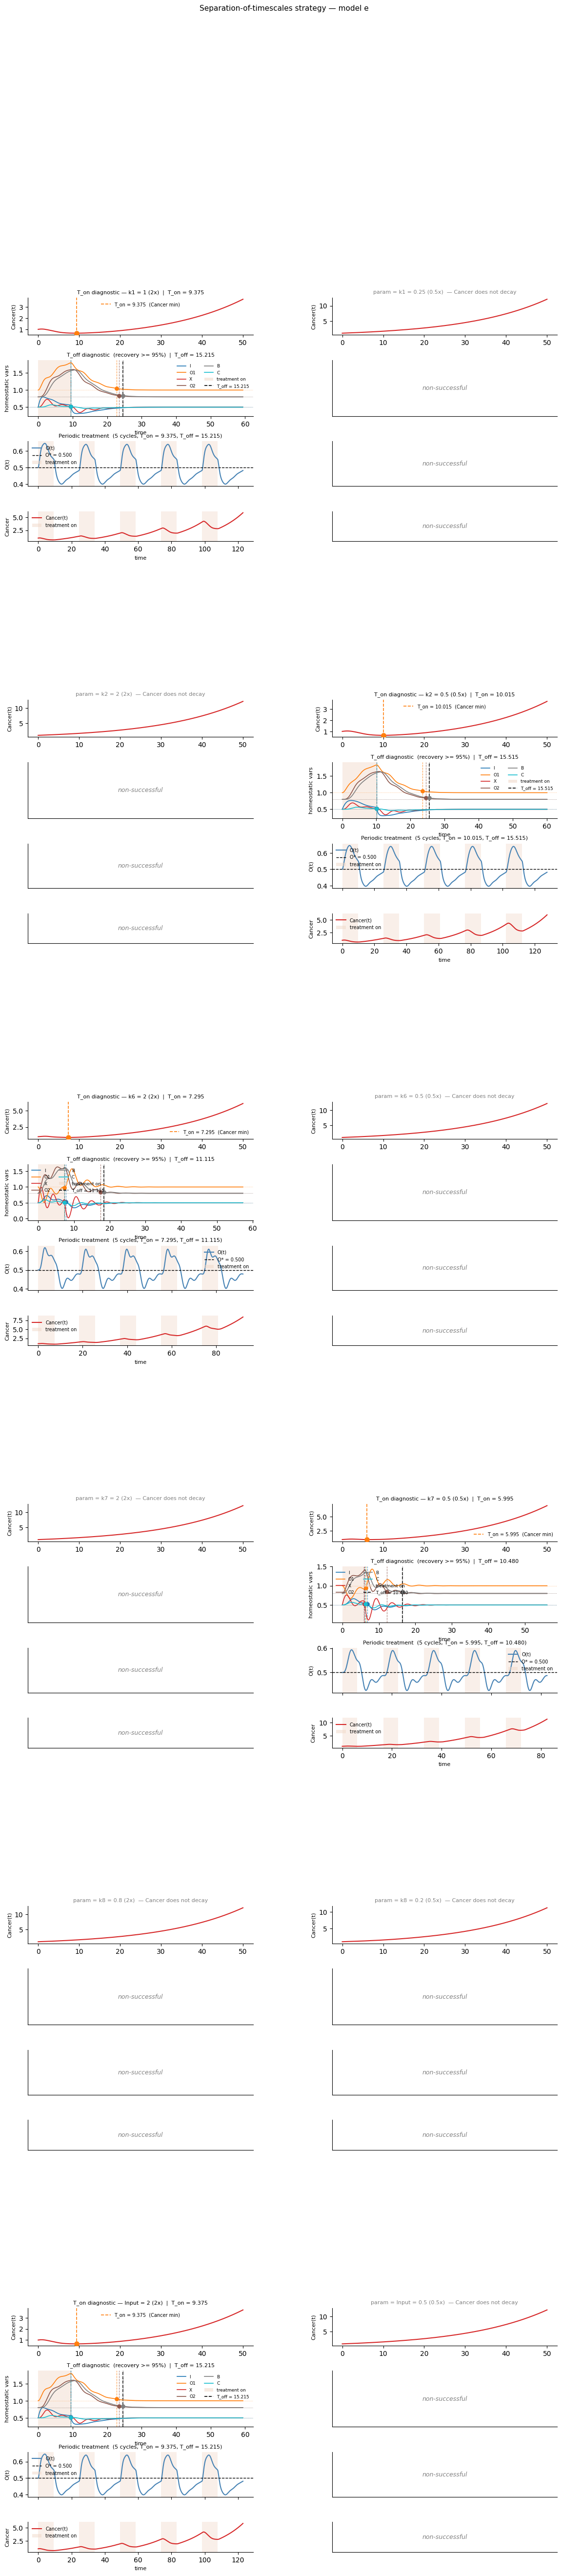

In [124]:
sot = run_sot_demo(model_e, n_cycles=5, t_max_ton=50, t_max_toff=50, recovery_frac=0.95)

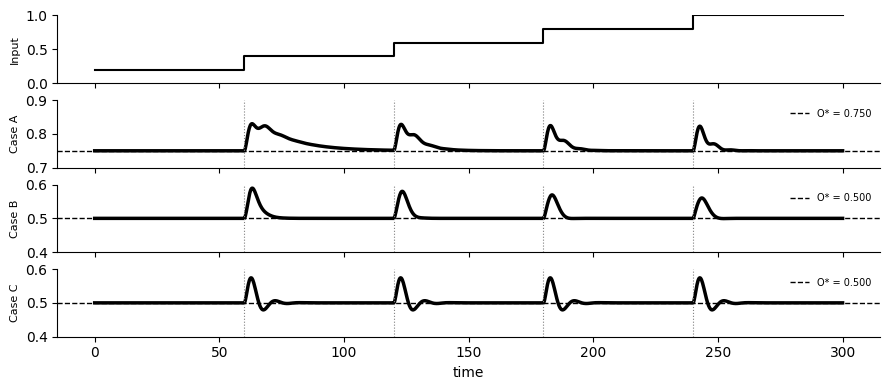

In [23]:
# ── Models a, b, c — stepped input, starting from SS at Input=0.2 ─────────────
input_vals = [0.2, 0.4, 0.6, 0.8, 1.0]
dt         = 60
t_seg      = np.linspace(0, dt, 300)

def stepped_trajectory(model, input_vals, dt, t_seg, y0=None):
    """Single continuous trajectory with piecewise-constant Input steps."""
    if y0 is None:
        y0 = np.ones(len(model.state_vars)) * 0.5
    y_cur, t_offset = y0.copy(), 0.0
    t_all, O_all = [], []
    for inp in input_vals:
        sol = solve_ivp(model.get_f({'Input': inp}), (0, dt), y_cur,
                        t_eval=t_seg, method='Radau', rtol=1e-8, atol=1e-10)
        t_all.append(sol.t + t_offset)
        O_all.append(sol.y[model.output_idx])
        y_cur     = sol.y[:, -1]
        t_offset += dt
    return np.concatenate(t_all), np.concatenate(O_all)

def eval_ss(model, input_val):
    """Evaluate the symbolic steady state at a given Input value."""
    subs = {sym: model.params_base[name]
            for name, sym in zip(model._param_names, model._sym_params)}
    subs[model._sym_input] = input_val
    return np.array([float(model._ss_dict[s].subs(subs)) for s in model._sym_state])

t_stairs = np.repeat(np.arange(len(input_vals) + 1) * dt, 2)[1:-1]
i_stairs = np.repeat(input_vals, 2)
t_vlines = np.arange(1, len(input_vals)) * dt
x_ticks  = np.arange(0, len(input_vals) * dt + 1, 50)

models_abc = [model_a, model_b, model_c]
ylims_abc  = [(0.7, 0.9), (0.4, 0.6), (0.4, 0.6)]
n = len(models_abc)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_abc, ylims_abc)):
    ax = axes[i + 1]

    y_ss_02 = eval_ss(model, 0.2)
    O_star  = float(y_ss_02[model.output_idx])

    t_cat, O_cat = stepped_trajectory(model, input_vals, dt, t_seg, y0=y_ss_02)

    ax.plot(t_cat, O_cat, color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()

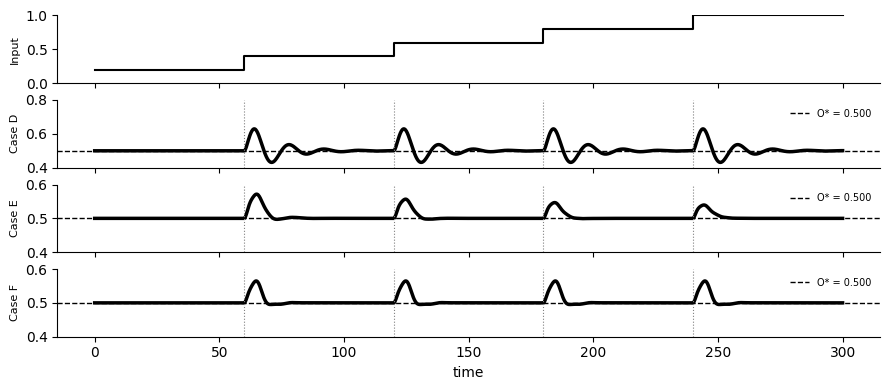

In [24]:
# ── Models d, e, f — stepped input, starting from SS at Input=0.2 ─────────────
models_def = [model_d, model_e, model_f]
ylims_def  = [(0.4, 0.8), (0.4, 0.6), (0.4, 0.6)]
n = len(models_def)

fig, axes = plt.subplots(n + 1, 1, figsize=(9, (n + 1) * 1.0), sharex=True)

axes[0].plot(t_stairs, i_stairs, color='k', lw=1.5)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Input', fontsize=8)
axes[0].tick_params(labelbottom=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for i, (model, ylim) in enumerate(zip(models_def, ylims_def)):
    ax = axes[i + 1]

    y_ss_02 = eval_ss(model, 0.2)
    O_star  = float(y_ss_02[model.output_idx])

    t_cat, O_cat = stepped_trajectory(model, input_vals, dt, t_seg, y0=y_ss_02)

    ax.plot(t_cat, O_cat, color='k', lw=2.5)
    ax.axhline(O_star, color='k', ls='--', lw=1, label=f'O* = {O_star:.3f}')
    for t_v in t_vlines:
        ax.axvline(t_v, color='grey', ls=':', lw=0.8)
    ax.set_ylim(*ylim)
    ax.set_ylabel(f'Case {model.name.upper()}', fontsize=8)
    ax.legend(fontsize=7, frameon=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel('time')
axes[-1].set_xticks(x_ticks)
plt.tight_layout(h_pad=0.2)
plt.show()